# Movie Data Analysis and Recommender System

The birth of the motion picture camera in the late 19th century gave rise to arguably the most potent form of storytelling in existence: Cinema. Audiences have been enthralled by the medium’s evolution—from the 1890s "horse in motion" clips to the introduction of "talkies" in the 1920s, the arrival of Technicolor in the 1930s, and the mainstream 3D spectacles of the early 2010s.

While cinema had humble origins—constrained by technical limitations in plot and duration—it has since been shaped by generations of creative geniuses. Today, movie industries worldwide span a vast spectrum of genres, from poignant romances to mind-bending science fiction.

Like most children of the last century, I grew up captivated by the enigmatic world of film. This notebook is an attempt to translate that fascination into insight using data. Leveraging a dataset of approximately 45,000 movies from TMDB, I will explore the trends that define the industry and build three distinct models:

- __Revenue Regressor__: A model to predict the box office performance of a given film.

- __Success Classifier__: A tool to identify whether a movie will be a "hit" or a financial loss for producers.

- __Hybrid Recommendation System__: An engine combining popularity, content-based, and collaborative filtering (utilizing both TMDB and MovieLens data) to suggest the perfect film.

### Installing dependencies and loading data

In [1]:

%matplotlib inline
from IPython.display import Image, HTML
import json
import datetime
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from wordcloud import WordCloud, STOPWORDS

import plotly.express as px
import plotly.graph_objects as go

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv('movies_metadata.csv')
df.head()

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\3991525872.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home, but that's a plan that -- like George -- will have to change with the arrival of both a grandchild and a kid of his own.",...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's In For The Surprise Of His Life!,Father of the Bride Part II,False,5.7,173.0


### Understanding the Dataset
The dataset above was obtained through the TMDB API. The movies available in this dataset are in correspondence with the movies that are listed in the __MovieLens Latest Full Dataset__ comprising of 26 million ratings on 45,000 movies from 27,000 users. Let us have a look at the features that are available to us.

In [3]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [4]:
df.shape

(45466, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

#### Features
- __adult__: Indicates if the movie is X-Rated or Adult.  
- __belongs_to_collection__: A stringified dictionary that gives information on the movie series the particular film belongs to.  
- __budget__: The budget of the movie in dollars.  
- __genres__: A stringified list of dictionaries that list out all the genres associated with the movie.  
- __homepage__: The Official Homepage of the move.  
- __id__: The ID of the move.  
- __imdb_id__: The IMDB ID of the movie.  
- __original_language__: The language in which the movie was originally shot in.  
- __original_title__: The original title of the movie.  
- __overview__: A brief blurb of the movie.  
- __popularity__: The Popularity Score assigned by TMDB.  
- __poster_path__: The URL of the poster image.  
- __production_companies__: A stringified list of production companies involved with the making of the movie.  
- __production_countries__: A stringified list of countries where the movie was shot/produced in.  
- __release_date__: Theatrical Release Date of the movie.  
- __revenue__: The total revenue of the movie in dollars.  
- __runtime__: The runtime of the movie in minutes.  
- __spoken_languages__: A stringified list of spoken languages in the film.  
- __status__: The status of the movie (Released, To Be Released, Announced, etc.)  
- __tagline__: The tagline of the movie.  
- __title__: The Official Title of the movie.  
- __video__: Indicates if there is a video present of the movie with TMDB.  
- __vote_average__: The average rating of the movie.  
- __vote_count__: The number of votes by users, as counted by TMDB.  


There are a total of __45,466 movies__ with __24 features__. Most of the features have very few NaN values (apart from __homepage__ and __tagline__). We will attempt at cleaning this dataset to a form suitable for analysis in the next section.


### Data Wrangling
The data that was originally obtained was in the form of a JSON File. This was converted manually into a CSV file to arrive at an input that could be loaded into a Pandas DataFrame effortlessly. In other words, the dataset we have in our hands is already relatively clean. We will however attempt at learning more about our features and performing appropriate wrangling steps to arrive at a form that is more suitable for analysis.

Let us start by removing the features that are not useful to us.

In [6]:
df = df.drop(['imdb_id'], axis =1)

In [7]:
df[df['original_title'] != df['title']][['title', 'original_title']].head()

,title,original_title
28,The City of Lost Children,La Cité des Enfants Perdus
29,Shanghai Triad,摇啊摇，摇到外婆桥
32,Wings of Courage,"Guillaumet, les ailes du courage"
57,The Postman,Il postino
58,The Confessional,Le confessionnal



The original title refers to the title of the movie in the native language in which the movie was shot. As such, I will prefer using the translated, Anglicized name in this analysis and hence, will drop the original titles altogether. We will be able to deduce if the movie is a foreign language film by looking at the __original_language__ feature so no tangible information is lost in doing so.

In [8]:
df = df.drop('original_title', axis=1)

In [9]:
df[df['revenue'] == 0].shape

(38052, 22)

We see that the majority of the movies have a recorded revenue of __0__. This indicates that we do not have information about the total revenue for these movies. Although this forms the majority of the movies available to us, we will still use revenue as an extremely important feature going forward from the remaining 7000 moves.

In [10]:
df['revenue'] = df['revenue'].replace(0, np.nan)


The __budget__ feature has some unclean values that makes Pandas assign it as a generic object. We proceed to convert this into a numeric variable and replace all the non-numeric values with NaN. Finally, as with budget, we will convert all the values of 0 with NaN to indicate the absence of information regarding budget.

In [11]:
df['budget'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 45466 entries, 0 to 45465
Series name: budget
Non-Null Count  Dtype 
--------------  ----- 
45466 non-null  object
dtypes: object(1)
memory usage: 355.3+ KB


In [12]:
df['budget'] = pd.to_numeric(df['budget'], errors = 'coerce')
df['budget'] = df['budget'].replace(0, np.nan)
df[df['budget'].isnull()].shape

(36576, 22)

In [13]:
df[['revenue', 'budget']].head()

,revenue,budget
0,373554033.0,30000000.0
1,262797249.0,65000000.0
2,NaN,NaN
3,81452156.0,16000000.0
4,76578911.0,NaN



As we move forward trying to answer certain questions, we will have to construct several features suitable for that particular query. For now, we will construct two very important features:

- __year__: The year in which the movie was released.
- __return__: The ratio of revenue to budget.


The return feature is extremely insightful as it will give us a more accurate picture of the financial success of a movie. Presently, our data will not be able to judge if a  200 million budget movie that earned 100 million did better than a 50,000 budget movie taking in 200,000. This feature will be able to capture that information.

A return value > 1 would indicate profit whereas a return value < 1 would indicate a loss.

In [14]:
df['return'] = df['revenue'] / df['budget']
df[df['return'].isnull()].shape

(40085, 23)


We have close to __5000 movies__ for which we have data on revenue and budget ratio. This is close to __10% of the entire dataset__. Although this may seem small, this is enough to perform very useful analysis and discover interesting insights about the world of movies.

In [15]:
df['return'].sample(10)

29595         NaN
23840         NaN
6150          NaN
42180         NaN
8921          NaN
17635    1.174316
32124         NaN
21942         NaN
9682          NaN
38314         NaN
Name: return, dtype: float64

In [16]:
df['release_date'].head()

0    1995-10-30
1    1995-12-15
2    1995-12-22
3    1995-12-22
4    1995-02-10
Name: release_date, dtype: object

In [17]:
df['year'] = pd.to_datetime(df['release_date'], errors = 'coerce').apply(lambda x: str(x).split('-')[0] if x != np.nan else np.nan)

In [18]:
df['year'].head()

0    1995
1    1995
2    1995
3    1995
4    1995
Name: year, dtype: object

In [19]:
df['adult'].value_counts()

adult
False                                                                                                                             45454
True                                                                                                                                  9
 - Written by Ørnås                                                                                                                   1
 Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.                        1
 Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.        1
Name: count, dtype: int64

There are close to __0 adult movies__ in this dataset. The __adult__ feature therefore is not of much use to us and can be safely dropped.

In [20]:
df = df.drop('adult', axis=1)

In [21]:
base_poster_url = 'http://image.tmdb.org/t/p/w185/'
df['poster_path'] = "<img src='" + base_poster_url + df['poster_path'] + "' style='height:100px;'>"

## Exploratory Data Analysis

### Title and Overview Wordclouds

Are there certain words that figure more often in Movie Titles and Movie Blurbs? I suspect there are some words which are considered more potent and considered more worthy of a title. Let us find out!

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  4494 non-null   object 
 1   budget                 8890 non-null   float64
 2   genres                 45466 non-null  object 
 3   homepage               7782 non-null   object 
 4   id                     45466 non-null  object 
 5   original_language      45455 non-null  object 
 6   overview               44512 non-null  object 
 7   popularity             45461 non-null  object 
 8   poster_path            45080 non-null  object 
 9   production_companies   45463 non-null  object 
 10  production_countries   45463 non-null  object 
 11  release_date           45379 non-null  object 
 12  revenue                7408 non-null   float64
 13  runtime                45203 non-null  float64
 14  spoken_languages       45460 non-null  object 
 15  st

In [23]:
df['title'] = df['title'].astype('str')
df['overview'] = df['overview'].astype('str')

In [24]:
title_corpus = ' '.join(df['title'])
overview_corpus = ' '.join(df['overview'])

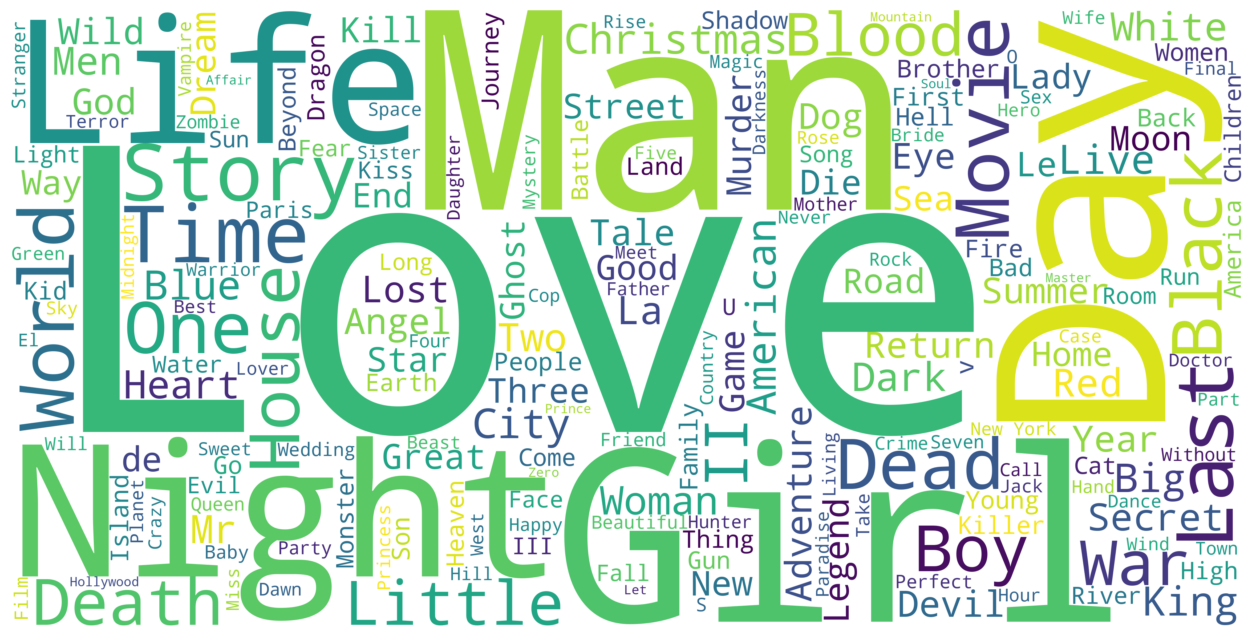

In [25]:
from wordcloud import WordCloud, STOPWORDS
title_wordcloud = WordCloud(
    stopwords=STOPWORDS,
    background_color='white',
    height=2000,
    width=4000
).generate(title_corpus)

plt.figure(figsize=(16,8))
plt.imshow(title_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


The word Love is the most commonly used word in movie titles. Girl, Day and Man are also among the most commonly occuring words. I think this encapsulates the idea of the ubiquitious presence of romance in movies pretty well.

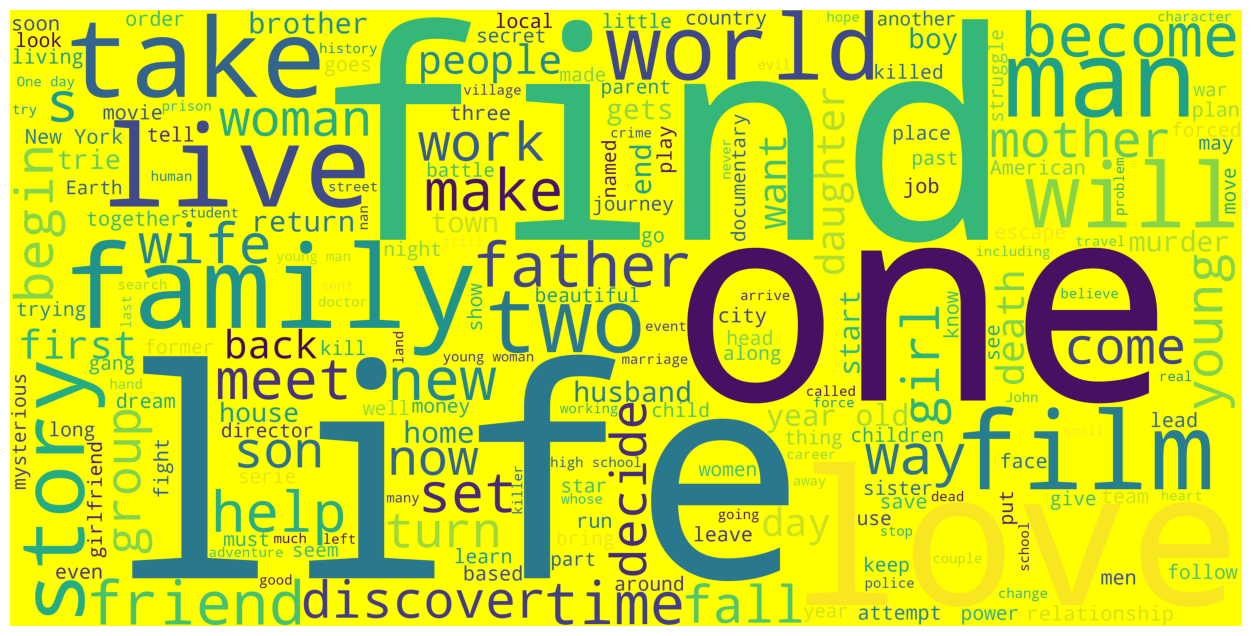

In [26]:

overview_wordcloud = WordCloud(
    stopwords=STOPWORDS, 
    background_color='yellow', 
    height=2000, 
    width=4000).generate(overview_corpus)

plt.figure(figsize=(16,8))
plt.imshow(overview_wordcloud)
plt.axis('off')
plt.show()

Life is the most commonly used word in Movie titles. One and Find are also popular in Movie Blurbs. Together with Love, Man and Girl, these wordclouds give us a pretty good idea of the most popular themes present in movies.


### Production Countries

The Full MovieLens Dataset consists of movies that are overwhelmingly in the English language (more than 31000). However, these movies may have shot in various locations around the world. It would be interesting to see which countries serve as the most popular destinations for shooting movies by filmmakers, especially those in the United States of America and the United Kingdom.

In [27]:
df['production_countries'].isnull().sum()
type(df['production_countries'][0])

str

In [28]:
df['production_countries'] = df['production_countries'].fillna('[]').apply(ast.literal_eval)

In [29]:
df['production_countries'] = df['production_countries'].apply(lambda x: [i['name'] for i in x]
                                                              if isinstance(x, list)
                                                              else[])

In [30]:
df['production_countries'].sample(10)

10248                                       [India]
39313                    [United States of America]
36643                 [Netherlands, Russia, France]
19166                                            []
2173     [United Kingdom, United States of America]
25850                                     [Finland]
616                        [France, Italy, Tunisia]
28427                    [United States of America]
8375                     [United States of America]
21440       [New Zealand, United States of America]
Name: production_countries, dtype: object

In [31]:
s = df.apply(lambda x: pd.Series(x['production_countries']), axis=1).stack().reset_index(level=1, drop=True)
s.name = 'countries'
s.head()

0    United States of America
1    United States of America
2    United States of America
3    United States of America
4    United States of America
Name: countries, dtype: object

In [32]:
con_df = (
    df.drop('production_countries', axis=1)
      .join(s)
)

con_df = con_df['countries'].value_counts().reset_index()
con_df.columns = ['country', 'num_movies']

con_df.head(10)

,country,num_movies
0,United States of America,21153
1,United Kingdom,4094
2,France,3940
3,Germany,2254
4,Italy,2169
5,Canada,1765
6,Japan,1648
7,Spain,964
8,Russia,912
9,India,828


Unsurprisingly, the __United States__ is the most popular destination of production for movies given that our dataset largely consists of English movies. __Europe__ is also an extremely popular location with the UK, France, Germany and Italy in the top 5. __Japan__ and __India__ are the most popular Asian countries when it comes to movie production.

In [33]:
con_df_filtered = con_df[con_df['country'] != 'United States of America']

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\572845462.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


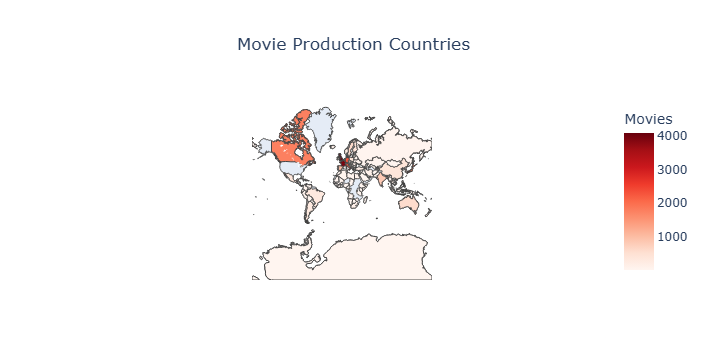

In [34]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Choropleth(
        locations=con_df_filtered['country'],
        locationmode='country names',
        z=con_df_filtered['num_movies'],
        text=con_df_filtered['country'],
        colorscale='Reds',
        hovertemplate=
        '<b>%{text}</b><br>' +
        'Movies: %{z}<extra></extra>',
        colorbar_title='Movies'
    )
)

fig.update_layout(
    title={
        'text': 'Movie Production Countries',
        'x': 0.5
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='mercator'
    )
)

fig.show()

## Franchise movies

Let us now have a brief look at Franchise movies. I was curious to discover the longest running and the most successful franchises among many other things. Let us wrangle our data to find out

In [35]:
df['belongs_to_collection'].head()

0              {'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}
1                                                                                                                                                                NaN
2        {'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}
3                                                                                                                                                                NaN
4    {'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}
Name: belongs_to_collection, dtype: object

In [36]:
df['belongs_to_collection'].notnull().sum()

np.int64(4494)

In [37]:
franc_df = df[df['belongs_to_collection'].notnull()]
franc_df.shape

(4494, 23)

In [38]:
franc_df['belongs_to_collection'].head(10)

0               {'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}
2         {'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}
4     {'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}
9                 {'id': 645, 'name': 'James Bond Collection', 'poster_path': '/HORpg5CSkmeQlAolx3bKMrKgfi.jpg', 'backdrop_path': '/6VcVl48kNKvdXOZfJPdarlUGOsk.jpg'}
12                 {'id': 117693, 'name': 'Balto Collection', 'poster_path': '/w0ZgH6Lgxt2bQYnf1ss74UvYftm.jpg', 'backdrop_path': '/9VM5LiJV0bGb1st1KyHA3cVnO2G.jpg'}
18             {'id': 3167, 'name': 'Ace Ventura Collection', 'poster_path': '/qCxH543pScFed1CycwJ1nVgrkOc.jpg', 'backdrop_path': '/bswWgdDsLu0fhWMYUzLF8XgiK4h.jpg'}
20  

In [39]:
franc_df['belongs_to_collection'] = franc_df['belongs_to_collection'].apply(ast.literal_eval).apply(lambda x: x['name']
                                                                            if isinstance(x, dict)
                                                                            else np.nan)

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\1988343827.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Highest Grossing Movie Franchises

In [40]:
fran_pivot = (
    franc_df
    .groupby('belongs_to_collection')['revenue']
    .agg(
        Total='sum',
        Average='mean',
        Number='count'
    )
    .sort_values('Total', ascending=False)
)

fran_pivot.head()

#Refined version of:
#fran_sum = pd.DataFrame(franc_df.groupby('belongs_to_collection')['revenue'].sum().sort_values(ascending=False))
#fran_sum.columns = ['Total']
#fran_mean = pd.DataFrame(franc_df.groupby('belongs_to_collection')['revenue'].mean().sort_values(ascending=False))
#fran_mean.columns = ['Average']
#fran_count = pd.DataFrame(franc_df.groupby('belongs_to_collection')['revenue'].count().sort_values(ascending=False))
#fran_count.columns = ['Number']

#fran_pivot = pd.concat((fran_sum, fran_mean, fran_count), axis=1)

,Total,Average,Number
belongs_to_collection,,,
Harry Potter Collection,7.707367e+09,9.634209e+08,8
Star Wars Collection,7.434495e+09,9.293118e+08,8
James Bond Collection,7.106970e+09,2.733450e+08,26
The Fast and the Furious Collection,5.125099e+09,6.406373e+08,8
Pirates of the Caribbean Collection,4.521577e+09,9.043154e+08,5



The __Harry Potter__ Franchise is the most successful movie franchise raking in more than 7.707 billion dollars from 8 movies. The __Star Wars__ Movies come in a close second with a 7.403 billion dollars from 8 movies too. __James Bond__ is third but the franchise has significantly more movies compared to the others in the list and therefore, a much smaller average gross.

### Most Successful Movie Franchises (by Average Gross)
We will use the average gross per movie to gauge the success of a movie franchise. However, this is not a very potent metric as the revenues in this dataset have not been adjusted for inflation. Therefore, revenue statistics will tend to strongly favor franchises in the recent times.

In [41]:

fran_pivot.sort_values('Average', ascending=False).head(10)

,Total,Average,Number
belongs_to_collection,,,
Avatar Collection,2.787965e+09,2.787965e+09,1
The Avengers Collection,2.924962e+09,1.462481e+09,2
Frozen Collection,1.274219e+09,1.274219e+09,1
Finding Nemo Collection,1.968906e+09,9.844532e+08,2
The Hobbit Collection,2.935523e+09,9.785078e+08,3
The Lord of the Rings Collection,2.916545e+09,9.721816e+08,3
Harry Potter Collection,7.707367e+09,9.634209e+08,8
Star Wars Collection,7.434495e+09,9.293118e+08,8
Despicable Me Collection,3.691070e+09,9.227676e+08,4


The __Avatar__ Collection, although just consisting of one movie at the moment, is the most successful franchise of all time with the sole movie raking in close to 3 billion dollars. The __Harry Potter__ franchise is still the most successful franchise with at least 5 movies.

### Longest Running Franchises
Finally, in this subsection, let us take a look at the franchises which have stood the test of time and have managed to deliver the largest number of movies under a single banner. This metric is potent in the way that it isn't affected by inflation. However, this does not imply that successful movie franchises tend to have more movies. Some franchises, such as Harry Potter, have a predefined storyline and it wouldn't make sense to produce more movies despite its enormous success.

In [42]:
fran_pivot.sort_values('Number', ascending=False).head(10)

,Total,Average,Number
belongs_to_collection,,,
James Bond Collection,7.106970e+09,2.733450e+08,26
Friday the 13th Collection,4.648985e+08,3.874155e+07,12
Pokémon Collection,6.983008e+08,6.348189e+07,11
Harry Potter Collection,7.707367e+09,9.634209e+08,8
The Fast and the Furious Collection,5.125099e+09,6.406373e+08,8
Halloween Collection,2.471681e+08,3.089601e+07,8
The Pink Panther (Original) Collection,1.644782e+08,2.055978e+07,8
A Nightmare on Elm Street Collection,3.635916e+08,4.544894e+07,8
Star Wars Collection,7.434495e+09,9.293118e+08,8


The __James Bond__ Movies is the largest franchise ever with over 26 movies released under the banner. __Friday the 13th__ and __Pokemon__ come in at a distant second and third with 12 and 11 movies respectively.

## Production Companies

In [43]:
df['production_companies'].head()

0                                                                                         [{'name': 'Pixar Animation Studios', 'id': 3}]
1    [{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]
2                                                        [{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]
3                                                                        [{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]
4                                           [{'name': 'Sandollar Productions', 'id': 5842}, {'name': 'Touchstone Pictures', 'id': 9195}]
Name: production_companies, dtype: object

In [44]:
df['production_companies'].isnull().sum()

np.int64(3)

In [45]:
df['production_companies'] = df['production_companies'].fillna('[]').apply(ast.literal_eval).apply(lambda x: [i['name'] for i in x]
                                                                                                   if isinstance(x,list)
                                                                                                   else [])

In [46]:
df['production_companies'].head()

0                                      [Pixar Animation Studios]
1    [TriStar Pictures, Teitler Film, Interscope Communications]
2                                 [Warner Bros., Lancaster Gate]
3                       [Twentieth Century Fox Film Corporation]
4                   [Sandollar Productions, Touchstone Pictures]
Name: production_companies, dtype: object

In [47]:
df['production_companies'].isnull().sum()

np.int64(0)

In [48]:
type(df['production_companies'])


pandas.core.series.Series

In [49]:

s = df.apply(lambda x: pd.Series(x['production_companies']),axis=1).stack().reset_index(level=1, drop=True)
s.name = 'companies'

In [50]:
com_df = df.drop('production_companies', axis = 1).join(s)
#com_df.head()

### Highest Earning Production Companies

Let us find out which production companies have earned the most money from the movie making business.

In [51]:
com_pivot = (
    com_df
    .groupby('companies')['revenue']
    .agg(
        Total='sum',
        Average='mean',
        Number='count'
    )
    .sort_values('Total', ascending=False)
)

com_pivot.head()

,Total,Average,Number
companies,,,
Warner Bros.,6.352519e+10,1.293792e+08,491
Universal Pictures,5.525919e+10,1.193503e+08,463
Paramount Pictures,4.880819e+10,1.235650e+08,395
Twentieth Century Fox Film Corporation,4.768775e+10,1.398468e+08,341
Walt Disney Pictures,4.083727e+10,2.778046e+08,147


__Warner Bros__ is the highest earning production company of all time earning a staggering 63.5 billion dollars from close to 500 movies. __Universal Pictures__ and __Paramaount Pictures__ are the second and the third highest earning companies with 55 billion dollars and 48 billion dollars in revenue respectively.

### Most Succesful Production Companies
Which production companies produce the most succesful movies on average? Let us find out. We will only consider those companies that have made at least 15 movies.

In [52]:
com_pivot[com_pivot['Number'] >= 15].sort_values('Average', ascending=False).head(10)

,Total,Average,Number
companies,,,
Pixar Animation Studios,1.118853e+10,6.215852e+08,18
Marvel Studios,1.169964e+10,6.157703e+08,19
Revolution Sun Studios,8.120339e+09,5.413559e+08,15
Lucasfilm,9.898421e+09,4.499282e+08,22
DreamWorks Animation,1.370752e+10,4.031622e+08,34
DC Entertainment,6.212609e+09,3.882880e+08,16
Dentsu,6.853205e+09,3.807336e+08,18
Jerry Bruckheimer Films,8.957441e+09,3.732267e+08,24
Marvel Enterprises,6.538067e+09,3.441088e+08,19


__Pixar Animation Studios__ has produced the most successful movies, on average. This is not surprising considering the amazing array of movies that it has produced in the last few decades: Up, Finding Nemo, Inside Out, Wall-E, Ratatouille, the Toy Story Franchise, Cars Franchise, etc. __Marvel Studios__ with an average gross of 615 million dollars comes in second with movies such as Iron Man and The Avengers under its banner.

## Original Language

In this section, let us look at the languages of the movies in our dataset. From the production countries, we have already deduced that the majority of the movies in the dataset are English. Let us see what the other major languages represented are.

In [53]:
df['original_language'].drop_duplicates().shape[0]

93

In [54]:
lang_df = pd.DataFrame(df['original_language'].value_counts())
lang_df.head()

,count
original_language,
en,32269
fr,2438
it,1529
ja,1350
de,1080



There are over __93 languages__ represented in our dataset. As we had expected, English language films form the overwhelmingly majority. French and Italian movies come at a very distant second and third respectively. Let us represent the most popular languages (apart from English) in the form of a bar plot.

In [55]:
lang_df['language'] = lang_df.index
lang_df.columns = ['number', 'language']
lang_df.head()

,number,language
original_language,,
en,32269,en
fr,2438,fr
it,1529,it
ja,1350,ja
de,1080,de


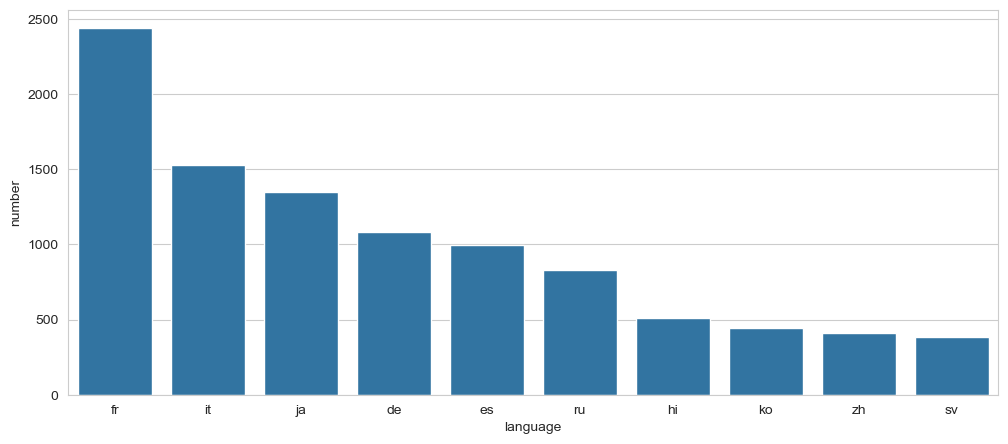

In [56]:
plt.figure(figsize=(12,5))
sns.barplot(x='language', y='number', data=lang_df.iloc[1:11])
plt.show()


As mentioned earlier, __French__ and __Italian__ are the most commonly occuring languages after English. __Japanese__ and __Hindi__ form the majority as far as Asian Languages are concerned.

## Popularity, Vote Average and Vote Count

In this section, we will work with metrics provided to us by TMDB users. We will try to gain a deeper understanding of the popularity, vote average and vote count features and try and deduce any relationships between them as well as other numeric features such as budget and revenue.

In [57]:
def clean_numeric(x):
    try:
        return float(x)
    except:
        return np.nan

In [58]:
df[['popularity', 'vote_count', 'vote_average']].isnull().sum()

popularity      5
vote_count      6
vote_average    6
dtype: int64

In [59]:
df['popularity'] = df['popularity'].apply(clean_numeric).astype('float')
df['vote_count'] = df['vote_count'].apply(clean_numeric).astype('float')
df['vote_average'] = df['vote_average'].apply(clean_numeric).astype('float')

Let us examine the summary statistics and the distribution of each feature one by one.

In [60]:
df['popularity'].describe()

count    45460.000000
mean         2.921478
std          6.005414
min          0.000000
25%          0.385948
50%          1.127685
75%          3.678902
max        547.488298
Name: popularity, dtype: float64

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\2251587667.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




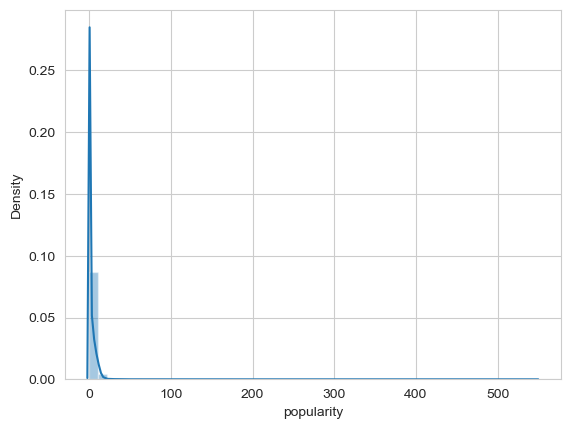

In [61]:
sns.distplot(df['popularity'].fillna(df['popularity'].median()))
plt.show()


The Popularity score seems to be an extremely skewed quentity with a mean of only 2.9 but maximum values reaching as high as 547, which is almost 1800% greater than the mean. However, as can be seen from the distribution plot, almost all movies have a popularity score less than 10 (the 75th percentile is at 3.678902

### Most popular movies by Popularity Score

In [62]:
df[['title', 'popularity', 'year']].sort_values('popularity', ascending=False).head(10)

,title,popularity,year
30700,Minions,547.488298,2015
33356,Wonder Woman,294.337037,2017
42222,Beauty and the Beast,287.253654,2017
43644,Baby Driver,228.032744,2017
24455,Big Hero 6,213.849907,2014
26564,Deadpool,187.860492,2016
26566,Guardians of the Galaxy Vol. 2,185.330992,2017
14551,Avatar,185.070892,2009
24351,John Wick,183.870374,2014
23675,Gone Girl,154.801009,2014


__Minions__ is the most popular movie by the TMDB Popularity Score. __Wonder Woman__ and __Beauty and the Beast__, two extremely succesful woman centric movies come in second and third respectively.

In [63]:
df['vote_count'].describe()

count    45460.000000
mean       109.897338
std        491.310374
min          0.000000
25%          3.000000
50%         10.000000
75%         34.000000
max      14075.000000
Name: vote_count, dtype: float64

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\460590556.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




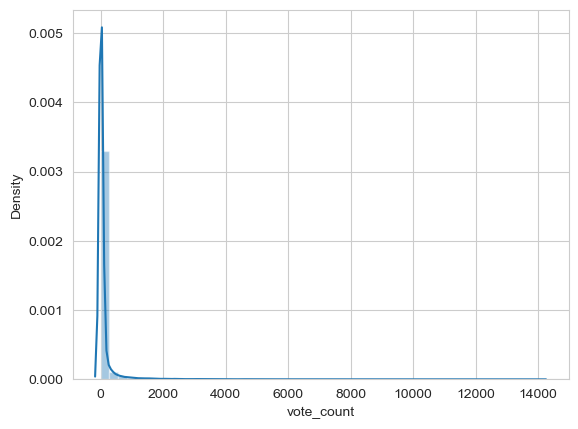

In [64]:
sns.distplot(df['vote_count'].fillna(df['vote_count'].median()))
plt.show()


As with popularity scores, the distribution of vote counts is extremely skewed with the median vote count standing at a paltry 10 votes. The most votes a single movie has got stands at 14,075. TMDB Votes, therefore, are not as potent and suggestive as its IMDB Counterpart. Nevertheless, let us check which the most voted on movies on the website are.

### Most Voted on movies

In [65]:
df[['title', 'vote_count', 'year']].sort_values('vote_count', ascending = False).head(10)

,title,vote_count,year
15480,Inception,14075.0,2010
12481,The Dark Knight,12269.0,2008
14551,Avatar,12114.0,2009
17818,The Avengers,12000.0,2012
26564,Deadpool,11444.0,2016
22879,Interstellar,11187.0,2014
20051,Django Unchained,10297.0,2012
23753,Guardians of the Galaxy,10014.0,2014
2843,Fight Club,9678.0,1999
18244,The Hunger Games,9634.0,2012



__Inception__ and __The Dark Knight__, two critically acclaimed and commerically successful Christopher Nolan movies figure at the top of our chart.

In [66]:
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['vote_average'].describe()

count    42462.000000
mean         6.014877
std          1.256208
min          0.500000
25%          5.300000
50%          6.100000
75%          6.900000
max         10.000000
Name: vote_average, dtype: float64

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\2060838323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




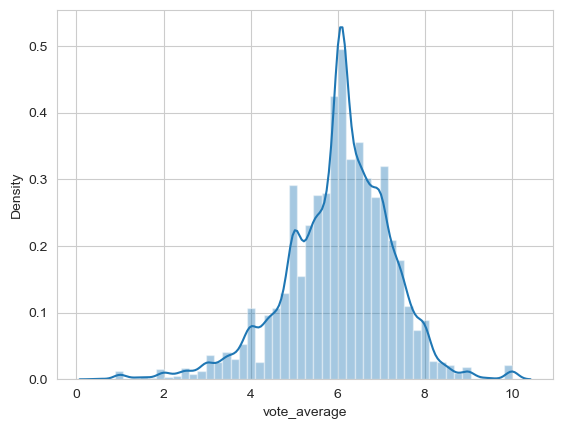

In [67]:
sns.distplot(df['vote_average'].fillna(df['vote_average'].median()))
plt.show()


It appears that TMDB Users are extremely strict in their ratings. The mean rating is only a 5.6 on a scale of 10. Half the movies have a rating of less than or equal to 6. Let us check what the most critically acclaimed movies as per TMDB are. We will only consider those movies that have more than 2000 votes (similar to IMDB's criteria of 5000 votes in selecting its top 250)

### Most critically aclaimed movies

In [68]:
df[df['vote_count'] > 2000][['title', 'vote_average', 'vote_count' ,'year']].sort_values('vote_average', ascending=False).head(10)

,title,vote_average,vote_count,year
314,The Shawshank Redemption,8.5,8358.0,1994
834,The Godfather,8.5,6024.0,1972
2211,Life Is Beautiful,8.3,3643.0,1997
5481,Spirited Away,8.3,3968.0,2001
1152,One Flew Over the Cuckoo's Nest,8.3,3001.0,1975
1176,Psycho,8.3,2405.0,1960
2843,Fight Club,8.3,9678.0,1999
1178,The Godfather: Part II,8.3,3418.0,1974
12481,The Dark Knight,8.3,12269.0,2008
292,Pulp Fiction,8.3,8670.0,1994



__The Shawshank Redemption__ and __The Godfather__ are the two most critically acclaimed movies in the TMDB Database. Interestingly, they are the top 2 movies in IMDB's Top 250 Movies list too. They have a rating of over 9 on IMDB as compared to their 8.5 TMDB Scores.

Do popularity and vote average share a tangible relationship? In other words, is there a strong positive correlation between these two quanitties? Let us visualise their relationship in the form of a scatterplot.

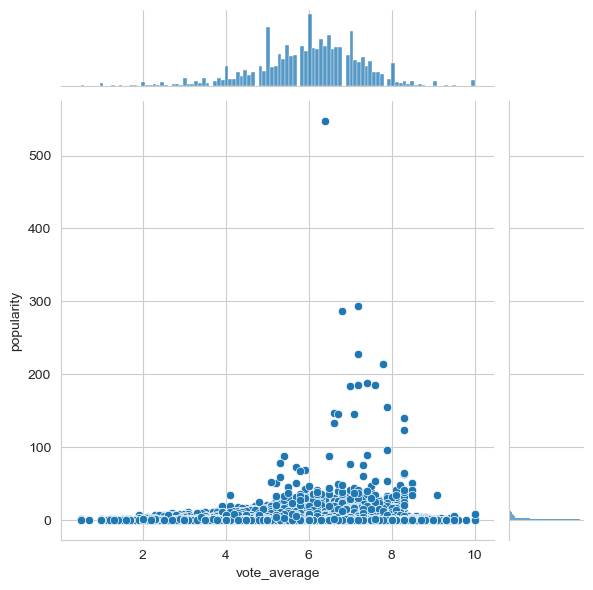

In [69]:
sns.jointplot(x = 'vote_average', y= 'popularity', data=df)

## Movie release date

Release Dates can often play a very important role in determining the success and the revenue generated by a particular movie. In this section, we will try and gain insights about release dates in terms of years, months and days of the week.

We have already constructed the year feature in our preliminary data wrangling step. Let us now extract the month and day too for each movie with a release date.

In [70]:

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

In [71]:
def get_month(x):
    try:
        return month_order[int(str(x).split('-')[1]) - 1]
    except:
        return np.nan

In [72]:

def get_day(x):
    try:
        year, month, day = (int(i) for i in x.split('-'))    
        answer = datetime.date(year, month, day).weekday()
        return day_order[answer]
    except:
        return np.nan

In [73]:
#Alternate way
#datetime.date(2026, 6 , 14).strftime('%A')

In [74]:
df['day'] = df['release_date'].apply(get_day)
df['month'] = df['release_date'].apply(get_month)

With these features in hand, let us now check the most popular and most successful months and days.

<Axes: title={'center': 'Number of Movies released in a particular month.'}, xlabel='month', ylabel='count'>

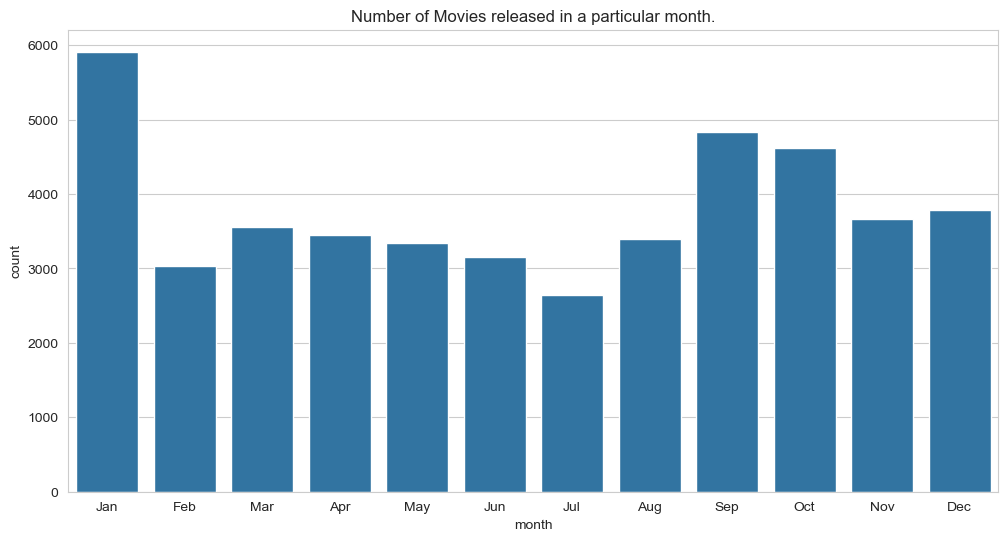

In [75]:
plt.figure(figsize=(12,6))
plt.title("Number of Movies released in a particular month.")
sns.countplot(x='month', data=df, order=month_order)


It appears that __January__ is the most popular month when it comes to movie releases. In Hollywood circles, this is also known as the the dump month when sub par movies are released by the dozen.

In which months do bockbuster movies tend to release? To answer this question, we will consider all movies that have made in excess of 100 million dollars and calculate the average gross for each month.

<Axes: title={'center': 'Average Gross by the Month for Blockbuster Movies'}, xlabel='month', ylabel='revenue'>

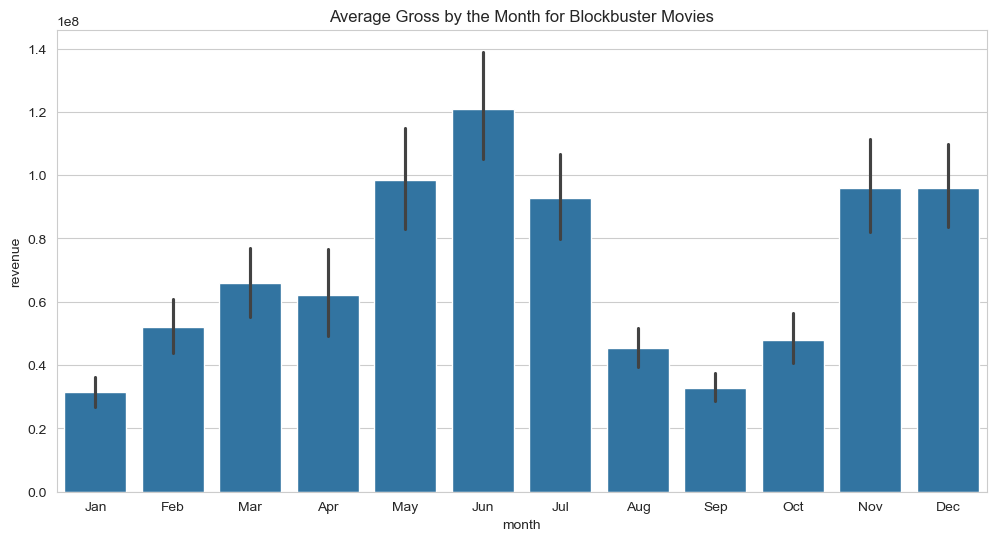

In [76]:
plt.figure(figsize=(12,6))
plt.title("Average Gross by the Month for Blockbuster Movies")
sns.barplot(x='month', y='revenue', data=df, order=month_order)

<Axes: title={'center': 'Average Gross by the Month for Blockbuster Movies'}, xlabel='mon', ylabel='revenue'>

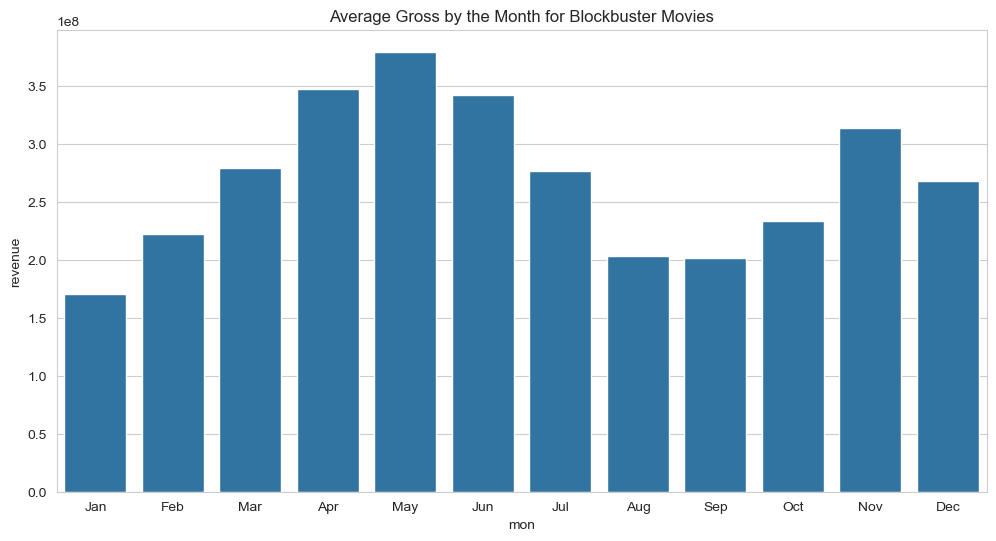

In [77]:

month_mean = pd.DataFrame(df[df['revenue'] > 1e8].groupby('month')['revenue'].mean())
month_mean['mon'] = month_mean.index
plt.figure(figsize=(12,6))
plt.title("Average Gross by the Month for Blockbuster Movies")
sns.barplot(x='mon', y='revenue', data=month_mean, order=month_order)


We see that the months of __April__, __May__ and __June__ have the highest average gross among high grossing movies. This can be attributed to the fact that blockbuster movies are usually released in the summer when the kids are out of school and the parents are on vacation and therefore, the audience is more likely to spend their disposable income on entertainment.

Do some months tend to be more successful than others? Let us visualise the boxplot between the return and the months.

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\1400667626.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




(0.0, 12.0)

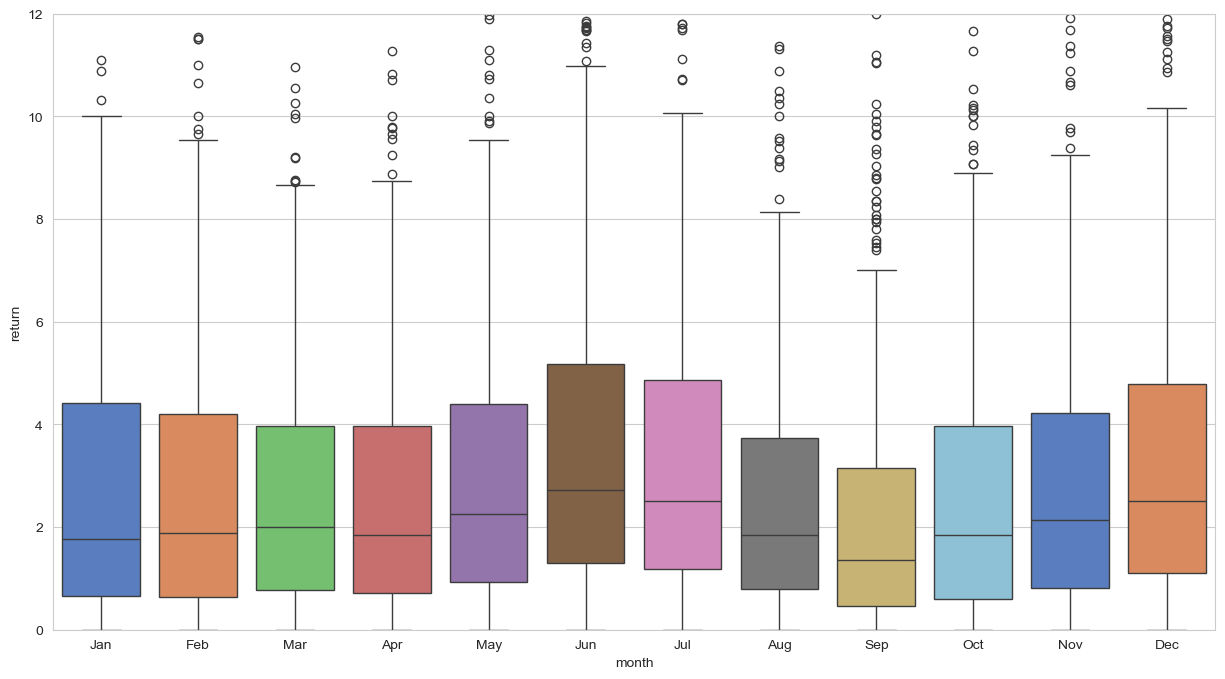

In [78]:

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15, 8))
sns.boxplot(x='month', y='return', data=df[df['return'].notnull()], palette="muted", ax =ax, order=month_order)
ax.set_ylim([0, 12])


The months of __June__ and __July__ tend to yield the highest median returns. __September__ is the least successful months on the aforementioned metrics. Again, the success of June and July movies can be attributed to them being summer months and times of vacation. September usually denotes the beginning of the school/college semester and hence a slight reduction in the consumption of movies.

Let us have a look at the most popular days as we did for months.

<Axes: title={'center': 'Number of Movies released on a particular day.'}, xlabel='day', ylabel='count'>

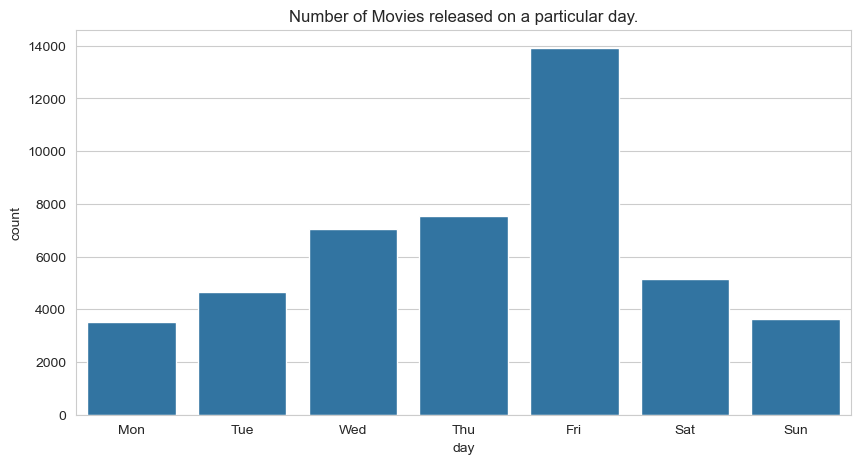

In [79]:
plt.figure(figsize=(10,5))
plt.title("Number of Movies released on a particular day.")
sns.countplot(x='day', data=df, order=day_order)


__Friday__ is clearly the most popular day for movie releases. This is understandable considering the fact that it usually denotes the beginning of the weekend. __Sunday__ and __Monday__ are the least popular days and this can be attributed to the same aforementioned reason.

#### Number of movies by the year  
The Dataset of 45,000 movies available to us does not represent the entire corpus of movies released since the inception of cinema. However, it is reasomnable to assume that it does include almost every major film released in Hollywood as well as other major film industries across the world (such as Bollywood in India). With this assumption in mind, let us take a look at the number of movies produced by the year

<Axes: xlabel='year'>

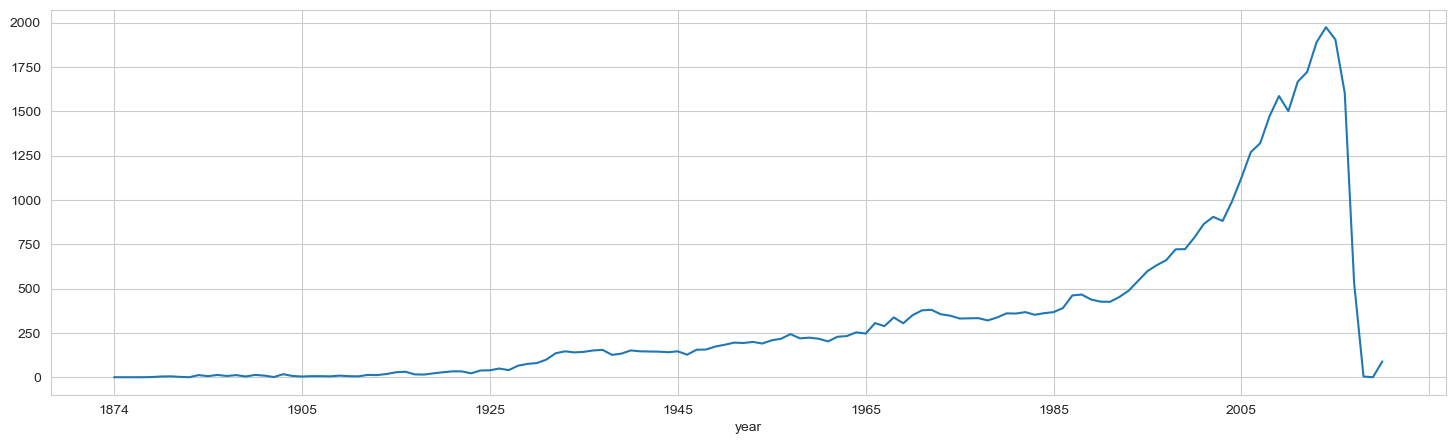

In [80]:
year_count = df.groupby('year')['title'].count()
plt.figure(figsize=(18,5))
year_count.plot()

We notice that there is a sharp rise in the number of movies __starting the 1990s decade.__ However, we will not look too much into this as it is entirely possible that recent movies were oversampled for the purposes of this dataset.  
Next, let us take a look at the earliest movies represented in the dataset.

#### Earliest movies represented

In [81]:
df[df['year'] != 'NaT'][['title', 'year']].sort_values('year').head(10)

,title,year
34940,Passage of Venus,1874
34937,Sallie Gardner at a Gallop,1878
41602,Buffalo Running,1883
34933,Man Walking Around a Corner,1887
34934,Accordion Player,1888
34938,Traffic Crossing Leeds Bridge,1888
34936,"Monkeyshines, No. 2",1890
34939,London's Trafalgar Square,1890
34935,"Monkeyshines, No. 1",1890
41194,Mosquinha,1890


The oldest movie, __Passage of Venus__, wss a series of photographs of the transit of the planet Venus across the Sun in 1874. They were taken in Japan by the French astronomer Pierre Janssen using his 'photographic revolver'. This is also the oldest movie on both IMDB and TMDB.  

Finally, in this section, let us construct a heatmap to indicate movie releases by month and year for all movies released in this century. This will give us a good idea of the hot and cold months for movie buffs.

In [82]:
months = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

In [83]:
df_21 = df.copy()
df_21['year'] = df_21[df_21['year'] != 'NaT']['year'].astype(int)
df_21 = df_21[df_21['year'] >=2000]
hmap_21 = pd.pivot_table(data=df_21, index='month', columns='year', aggfunc='count', values='title')
hmap_21 = hmap_21.fillna(0)

<Axes: xlabel='year', ylabel='month'>

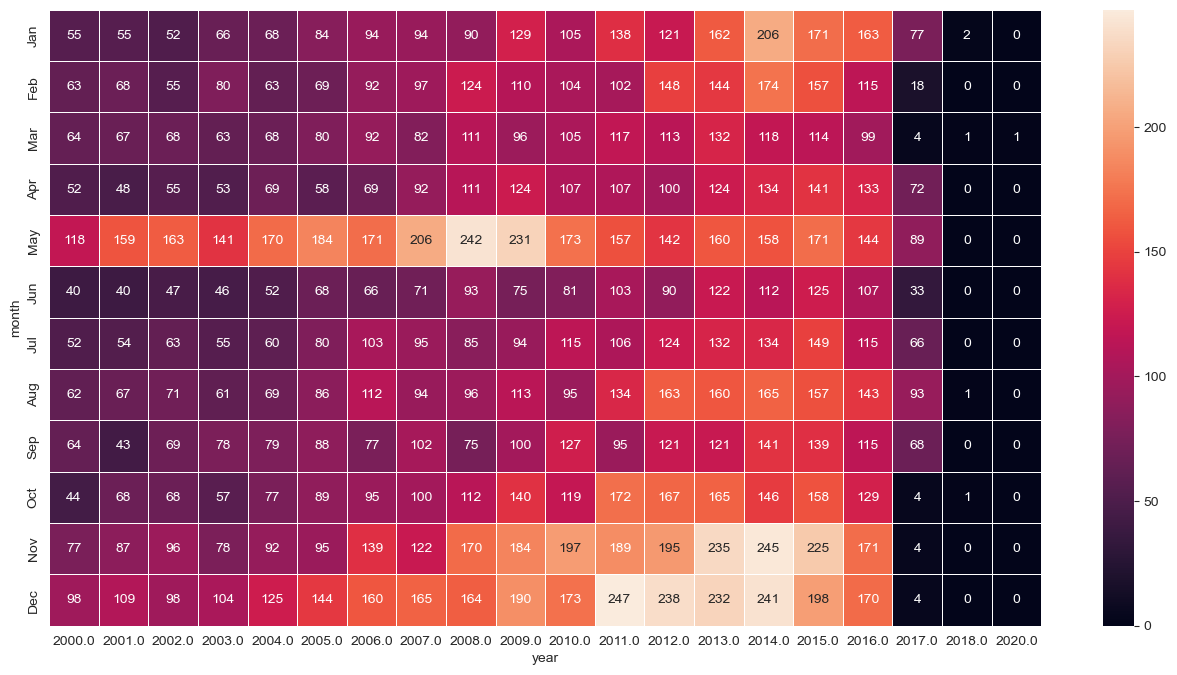

In [84]:
f, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(hmap_21, annot=True, linewidths=.5, ax=ax, fmt='n', yticklabels=month_order)

### Movie Status
Although not entirely relevant to our analysis of movies, gathering information on the various kinds of movies based on their status of release can provide us interesitng insight on the nature of the movies present in our dataset. My preliminary hunch was that almost every movie has the Released status. Let's find out.

In [85]:
df['status'].value_counts()

status
Released           45014
Rumored              230
Post Production       98
In Production         20
Planned               15
Canceled               2
Name: count, dtype: int64

Almost every movie is indeed released. However, it is interesting to see that MovieLens has user ratings for movies that are still in the planning, production and post production stage. We might take this information into account while building our collaborative filtering recommendation engine.

### Spoken Languages
Does the number of spoken languages influence the success of a movie? To do this, we will convert our spoken_languages feature to a numeric feature denoting the number of languages spoken in that film

In [86]:
df['spoken_languages'] = df['spoken_languages'].fillna('[]').apply(ast.literal_eval).apply(lambda x: len(x) if isinstance(x, list) else np.nan)

In [87]:

df['spoken_languages'].value_counts()

spoken_languages
1     33736
2      5371
0      3835
3      1705
4       550
5       178
6        62
7        14
8         6
9         5
10        1
12        1
19        1
13        1
Name: count, dtype: int64

Most movies have just one language spoken in the entire duration of the film. 19 is the higest number of languages spoken in a film. Let us take a look at all the films with more than 10 spoken languages.

In [88]:
df[df['spoken_languages'] >= 10][['title', 'year', 'spoken_languages']].sort_values('spoken_languages', ascending = False)

,title,year,spoken_languages
22235,Visions of Europe,2004,19
35288,The Testaments,2000,13
14093,To Each His Own Cinema,2007,12
8789,The Adventures of Picasso,1978,10


The movie with the most number of languages, __Visions of Europe__ is actually a collection of 25 short films by 25 different European directors. This explains the sheer diversity of the movie in terms of language.

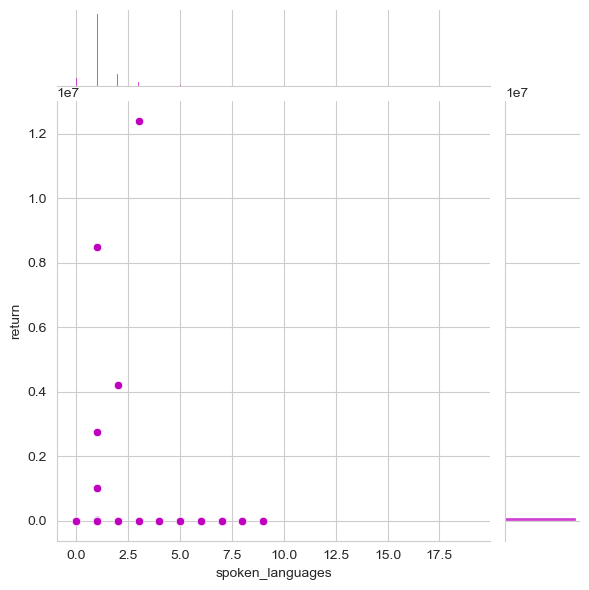

In [89]:
sns.jointplot(
    x="spoken_languages",
    y="return",
    data=df,
    color="m"
)

In [90]:
corr, p_value = stats.spearmanr(
    df['spoken_languages'],
    df['return'],
    nan_policy='omit'
)

print(f"Spearman correlation: {corr:.3f}")
print(f"P-value: {p_value:.4g}")

Spearman correlation: 0.018
P-value: 0.1874



The Spearman Coefficient is __0.018__ indicating no correlation between the two quantities.

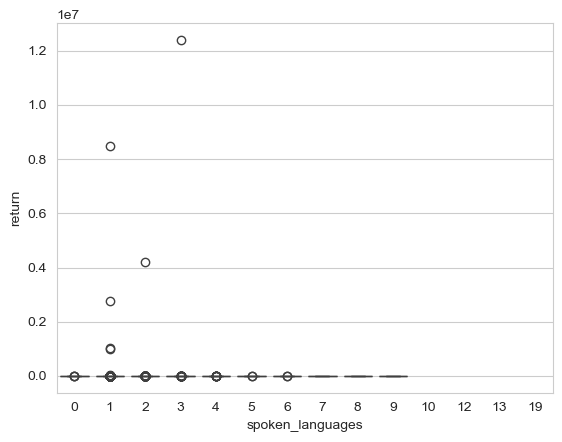

In [91]:
sns.boxplot(
    data=df,
    x='spoken_languages',
    y='return'
)

plt.show()


### Runtime
From its humble beginnings of 1 minute slient, black & white clips to epic 3 hour visual delights, movies have a come a long way in terms of runtime. In this section, let us try and gain some additional insights about the nature of movie lengths and their evolution over time.

In [92]:
df['runtime'].describe()


count    45203.000000
mean        94.128199
std         38.407810
min          0.000000
25%         85.000000
50%         95.000000
75%        107.000000
max       1256.000000
Name: runtime, dtype: float64


The average length of a movie is about 1 hour and 30 minutes.   
The longest movie on record in this dataset is a staggering 1256 minutes (or 20 hours) long.

In [93]:
df['runtime'] = df['runtime'].astype('float')



We are aware that most movies are less than 5 hours (or 300 minutes) long. Let us plot a distribution of these mainstream movies.

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\1496616792.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='runtime', ylabel='Density'>

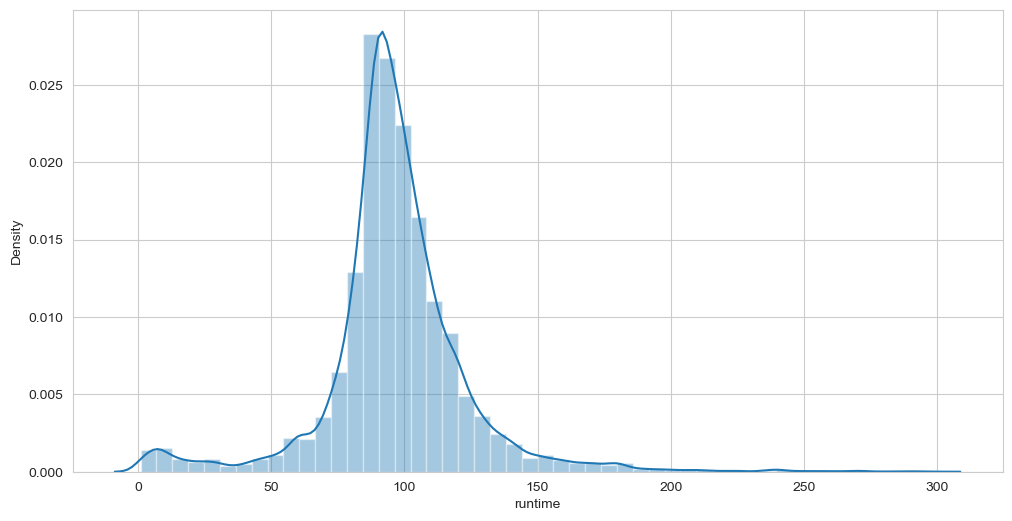

In [94]:

plt.figure(figsize=(12,6))
sns.distplot(df[(df['runtime'] < 300) & (df['runtime'] > 0)]['runtime'])


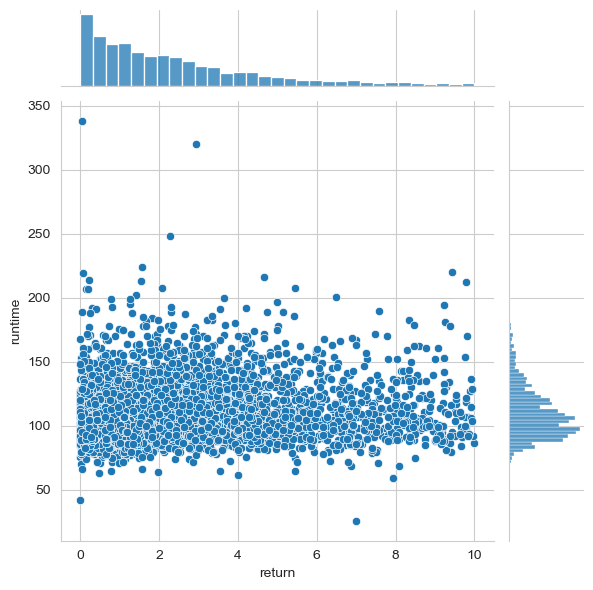

In [95]:

df_mat = df[(df['return'].notna()) & (df['runtime'] > 0) & (df['return'] < 10)]
sns.jointplot(data=df_mat, x='return', y='runtime')

plt.show()

There seems to be relationship between the two quantities. __The duration of a movie is independent of its success__. However, I have a feeling this might not be the case with duration and budget. A longer movie should entail a higher budget. Let us find out if this is really the case.

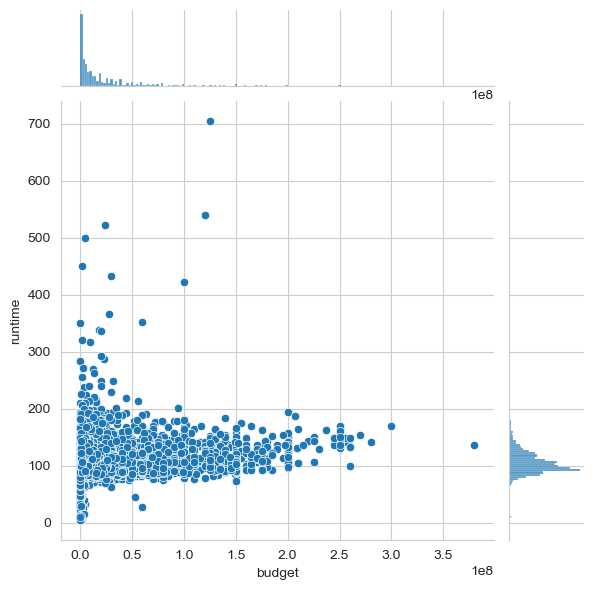

In [96]:

df_mat = df[(df['budget'].notna()) & (df['runtime'] > 0)]
sns.jointplot(x='budget', y='runtime', data=df_mat)
plt.show()

The two quantities have a much weaker correlation than I had expected. In retrospect, the genre of the movie tends to have a much greater impact on budget. A 3 hour art film will cost significantly lesser than a 90 minute Sci-Fi movie.

Next, I'd like to see the average lengths of movies through time, right from the 1890s to the 2017s. It would be interesting to see the trends in what filmmakers adjudged would be the appropriate length of a movie at that time.

TypeError: arange() not supported for inputs with DType <class 'numpy.dtypes.StrDType'>.

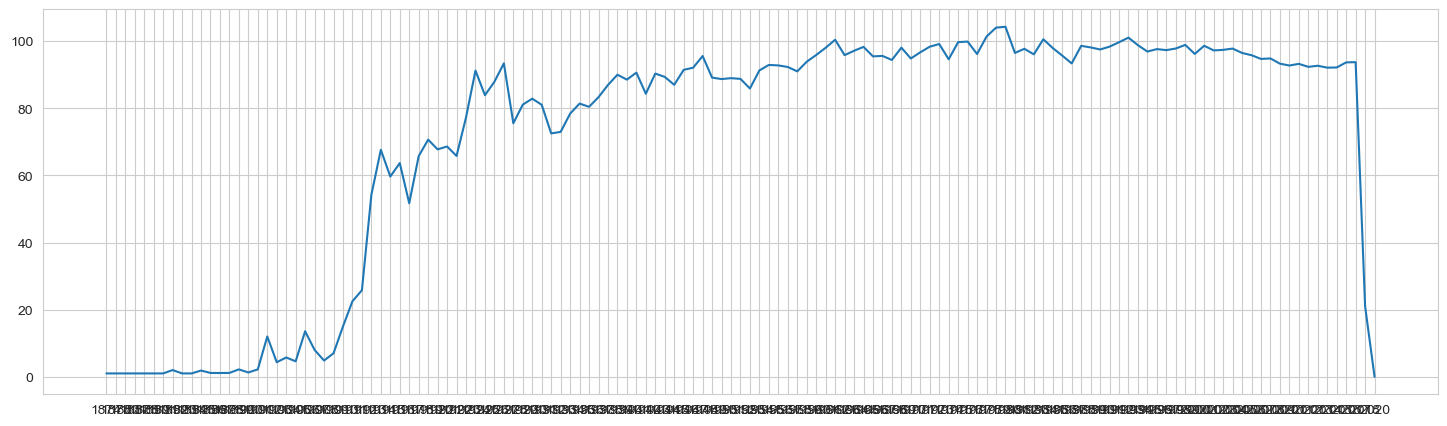

In [99]:
plt.figure(figsize=(18,5))
year_runtime = df[df['year'] != 'NaT'].groupby('year')['runtime'].mean()
plt.plot(year_runtime.index, year_runtime)
plt.xticks(
    np.arange( year_runtime.index.min(), year_runtime.index.max() , 10.0)
    )

plt.show()

In [100]:
year_runtime.index.min()

'1874'


We notice that films started hitting the 60 minute mark as early as 1914. Starting 1924, films started having the traiditonal 90 minute duration and has remained more or less constant ever since.

Finally in this section, let us see the longest and the shortest movies of all time (with respect to the movies in the dataset).

#### Shortest movies

In [101]:
df[df['runtime'] > 0][['runtime', 'title', 'year']].sort_values('runtime').head(10)


,runtime,title,year
35146,1.0,La Vague,1891
36577,1.0,Champs de Mars,1900
36576,1.0,Palace of Electricity,1900
44965,1.0,"Luis Martinetti, Contortionist",1894
42357,1.0,A Gathering of Cats,2007
36575,1.0,Eiffel Tower from Trocadero Palace,1900
36574,1.0,Panorama of Eiffel Tower,1900
44714,1.0,The Infernal Caldron,1903
19244,1.0,The Kiss,1896
44646,1.0,The Vanishing Lady,1896


We see that every movie in this list except A Gathering of Cats were filmed in the late 1890s and the beginning of the 20th century. All these movies were one minute long.

#### Longest movies

In [102]:
df[df['runtime'] > 0][['runtime', 'title', 'year']].sort_values('runtime', ascending=False).head(10)

,runtime,title,year
24178,1256.0,Centennial,1978
40938,1140.0,Baseball,1994
19965,1140.0,Jazz,2001
13767,931.0,Berlin Alexanderplatz,1980
13953,925.0,Heimat: A Chronicle of Germany,1984
27855,900.0,The Story of Film: An Odyssey,2011
26682,877.0,Taken,2002
19158,874.0,The War,2007
34667,840.0,The Roosevelts: An Intimate History,2014
34732,840.0,Seventeen Moments in Spring,1973



We notice that almost all the entries in the above chart are actually miniseries and hence, do not count as feature length films. We cannot gather too much insight from this list of longest movies as there is no way of distinguishing feature length films from TV Mini Series from our dataset (except, of course, by doing it manually).

### Budget  
Let us now turn our attention to budget. We expect budgets to be a skewed quantity and also heavily influenced by inflation. Nevertheless, it would be interesting to gather as much insights as possible from this quantity as budget is often a critical feature in predicting movie revenue and success. As a start, let us gather the summary statistics for our budget.

In [103]:
df['budget'].describe()

count    8.890000e+03
mean     2.160428e+07
std      3.431063e+07
min      1.000000e+00
25%      2.000000e+06
50%      8.000000e+06
75%      2.500000e+07
max      3.800000e+08
Name: budget, dtype: float64


The mean budget of a film is 21.6 million dollars whereas the median budget is far smaller at 8 million dollars. This strongly suggests the mean being influenced by outliers.

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\1917904569.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='budget', ylabel='Density'>

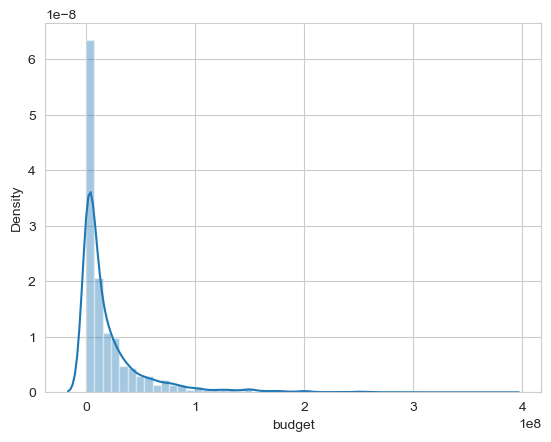

In [104]:
sns.distplot(df[df['budget'].notnull()]['budget'])


The distribution of movie budgets shows an exponential decay. More than 75% of the movies have a budget smaller than 25 million dollars. Next, let us take a look at the most expensive movies of all time and the revenue & returns that they generated.

In [105]:
df[df['budget'].notnull()][['title', 'budget', 'revenue', 'return', 'year']].sort_values('budget', ascending=False).head(10)


,title,budget,revenue,return,year
17124,Pirates of the Caribbean: On Stranger Tides,380000000.0,1.045714e+09,2.751878,2011
11827,Pirates of the Caribbean: At World's End,300000000.0,9.610000e+08,3.203333,2007
26558,Avengers: Age of Ultron,280000000.0,1.405404e+09,5.019299,2015
11067,Superman Returns,270000000.0,3.910812e+08,1.448449,2006
44842,Transformers: The Last Knight,260000000.0,6.049421e+08,2.326701,2017
16130,Tangled,260000000.0,5.917949e+08,2.276134,2010
18685,John Carter,260000000.0,2.841391e+08,1.092843,2012
11780,Spider-Man 3,258000000.0,8.908716e+08,3.452991,2007
21175,The Lone Ranger,255000000.0,8.928991e+07,0.350157,2013
22059,The Hobbit: The Desolation of Smaug,250000000.0,9.584000e+08,3.833600,2013


Two __Pirates of the Carribean__ films occupy the top spots in this list with a staggering budget of over __300 million dollars__. All the top 10 most expensive films made a profit on their investment except for __The Lone Ranger__ which managed to recoup less than 35% of its investment, taking in a paltry 90 million dollars on a __255 million dollar__ budget.

How strong a correlation does the budget hold with the revenue? A stronger correlation would directly imply more accurate forecasts.

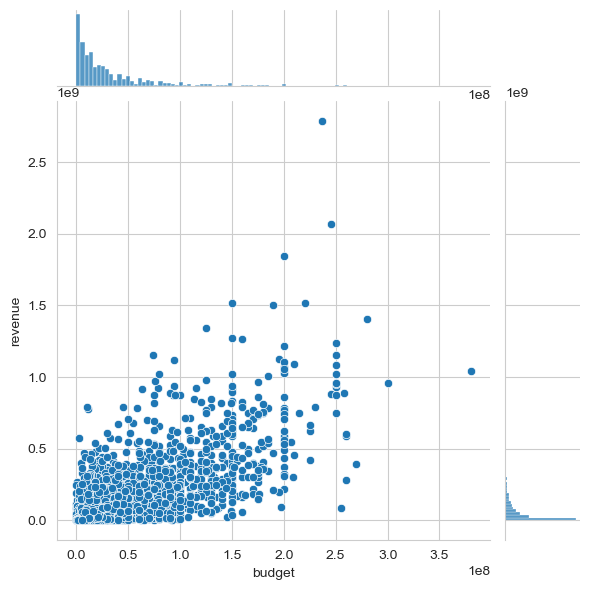

In [106]:
sns.jointplot(x='budget',y='revenue',data=df[df['return'].notnull()])


### Revenue
The final numeric feature we will explore is the revenue. The revenue is probably the most important numeric quantity associated with a movie. We will try to predict the revenue for movies given a set of features in a later section. The treatment of revenue will be very similar to that of budget and we will once again begin by studying the summary statistics.

In [107]:
df['revenue'].describe()

count    7.408000e+03
mean     6.878739e+07
std      1.464203e+08
min      1.000000e+00
25%      2.400000e+06
50%      1.682272e+07
75%      6.722707e+07
max      2.787965e+09
Name: revenue, dtype: float64


The mean gross of a movie is __68.7 million dollars__ whereas the median gross is much lower at __16.8 million dollars__, suggesting the skewed nature of revenue. The lowest revenue generated by a movie is __just 1 dollar__ whereas the highest grossing movie of all time has raked in an astonishing **2.78 billion dollars.**

C:\Users\sahaj\AppData\Local\Temp\ipykernel_24956\3976772722.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='revenue', ylabel='Density'>

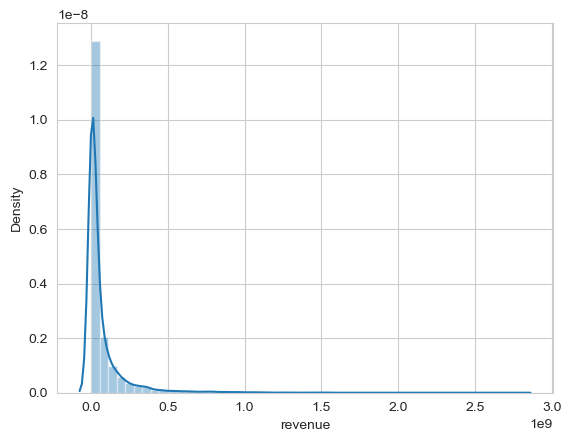

In [108]:
sns.distplot(df[df['revenue'].notnull()]['revenue'])

In [109]:

gross_top = df[['poster_path', 'title', 'budget', 'revenue', 'year']].sort_values('revenue', ascending=False).head(10)
pd.set_option('display.max_colwidth', 100)
HTML(gross_top.to_html(escape=False))

,poster_path,title,budget,revenue,year
14551,,Avatar,237000000.0,2.787965e+09,2009
26555,,Star Wars: The Force Awakens,245000000.0,2.068224e+09,2015
1639,,Titanic,200000000.0,1.845034e+09,1997
17818,,The Avengers,220000000.0,1.519558e+09,2012
25084,,Jurassic World,150000000.0,1.513529e+09,2015
28830,,Furious 7,190000000.0,1.506249e+09,2015
26558,,Avengers: Age of Ultron,280000000.0,1.405404e+09,2015
17437,,Harry Potter and the Deathly Hallows: Part 2,125000000.0,1.342000e+09,2011
22110,,Frozen,150000000.0,1.274219e+09,2013
42222,,Beauty and the Beast,160000000.0,1.262886e+09,2017


In [110]:
pd.set_option('display.max_colwidth', 50)

These figures have not been adjusted for inflation. Therefore, we see a disproportionate number of movies from very recent times in the top 10 list. To get an understanding of the revenue garnered by movies, let us plot the maximum revenue through the years.

TypeError: arange() not supported for inputs with DType <class 'numpy.dtypes.StrDType'>.

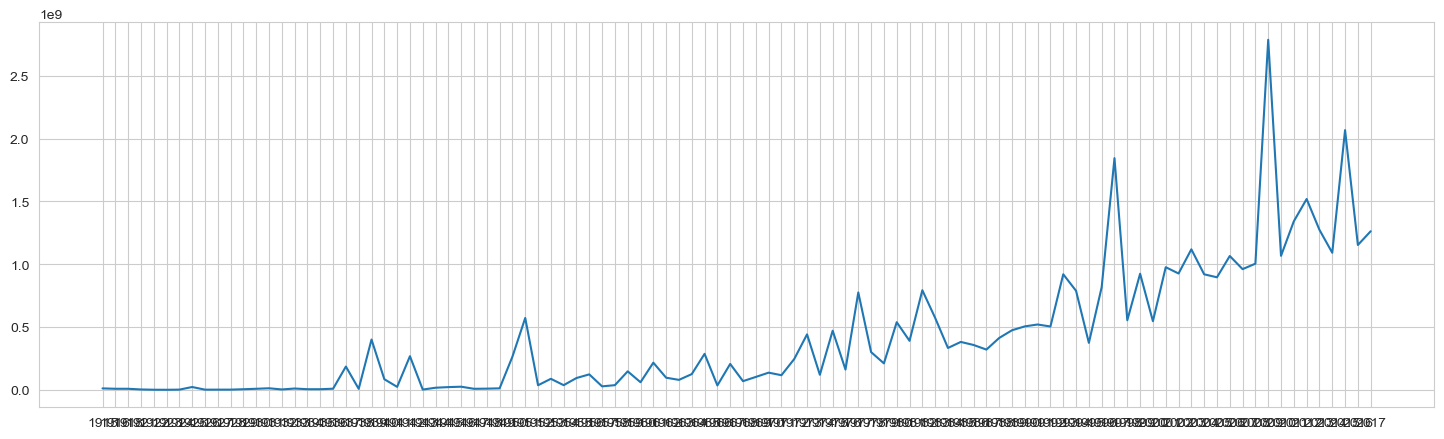

In [111]:

plt.figure(figsize=(18,5))
year_revenue = df[(df['revenue'].notnull()) & (df['year'] != 'NaT')].groupby('year')['revenue'].max()
plt.plot(year_revenue.index, year_revenue)
plt.xticks(np.arange(year_runtime.index.min(), year_runtime.index.max() , 10.0))
plt.show()


As can be seen from the figure, the maximum gross has steadily risen over the years. The world of movies broke the 1 billion dollar mark in 1997 with the release of __Titanic__. It took another 12 years to break the 2 billion dollar mark with __Avatar__. Both these movies were directed by James Cameron.

### Returns
We will not look too much into returns for the time being. Let us just check the least and the most successful movies of all time. To do this, we will only consider those movies which have a budget greater than 5 million dollars.

#### Most Successful Movies

In [112]:
df[(df['return'].notnull()) & (df['budget'] > 5e6)][['title', 'budget', 'revenue', 'return', 'year']].sort_values('return', ascending=False).head(10)

,title,budget,revenue,return,year
1065,E.T. the Extra-Terrestrial,10500000.0,792965326.0,75.520507,1982
256,Star Wars,11000000.0,775398007.0,70.490728,1977
1338,Jaws,7000000.0,470654000.0,67.236286,1975
1888,The Exorcist,8000000.0,441306145.0,55.163268,1973
352,Four Weddings and a Funeral,6000000.0,254700832.0,42.450139,1994
834,The Godfather,6000000.0,245066411.0,40.844402,1972
4492,Look Who's Talking,7500000.0,296000000.0,39.466667,1989
24258,Annabelle,6500000.0,255273813.0,39.272894,2014
1056,Dirty Dancing,6000000.0,213954274.0,35.659046,1987
1006,The Sound of Music,8200000.0,286214286.0,34.904181,1965


#### Worst Box Office Disasters

In [113]:
df[(df['return'].notnull()) & (df['budget'] > 5e6) & (df['revenue'] > 10000)][['title', 'budget', 'revenue', 'return', 'year']].sort_values('return').head(10)

,title,budget,revenue,return,year
11159,Chaos,20000000.0,10289.0,0.000514,2005
19027,5 Days of War,20000000.0,17479.0,0.000874,2011
21034,Special Forces,10000000.0,10759.0,0.001076,2011
25732,Foodfight!,65000000.0,73706.0,0.001134,2012
38388,Term Life,16500000.0,21256.0,0.001288,2016
19505,Laurence Anyways,9500000.0,12250.0,0.001289,2012
12038,The Good Night,15000000.0,20380.0,0.001359,2007
3966,Cherry 2000,10000000.0,14000.0,0.001400,1987
22097,Twice Born,13000000.0,18295.0,0.001407,2012
5651,All The Queen's Men,15000000.0,23000.0,0.001533,2001


With these analyses in place, we are in a good position to construct our correlation matrix.

In [114]:
df['year'] = df['year'].replace('NaT', np.nan)

In [115]:
df['year'] = df['year'].apply(clean_numeric)

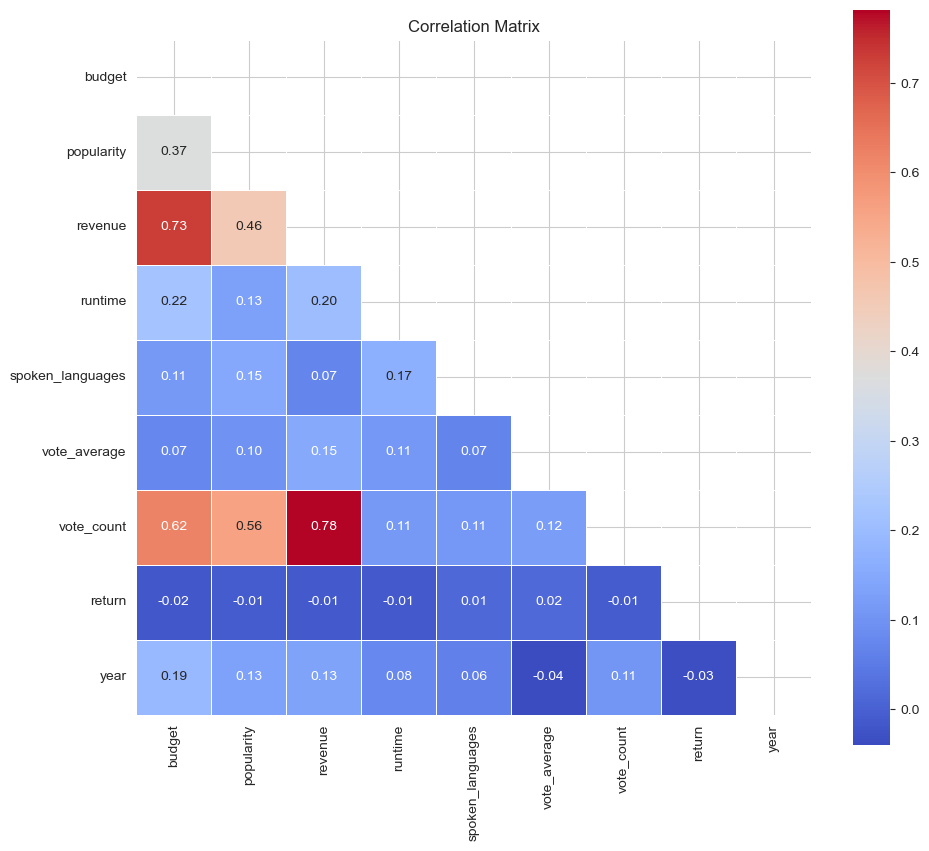

In [116]:
# Compute correlation matrix using only numeric columns
corr = df.select_dtypes(include=np.number).corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Genres

In [117]:
df['genres'] = df['genres'].fillna('[]').apply(ast.literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [118]:
s = df.apply(lambda x: pd.Series(x['genres']),axis=1).stack().reset_index(level=1, drop=True)
s.name = 'genre'

In [119]:
gen_df = df.drop('genres', axis=1).join(s)

In [120]:
gen_df['genre'].value_counts().shape[0]

32

TMDB defines 32 different genres for our set of 45,000 movies. Let us now have a look at the most commonly occuring genres in movies.

In [121]:
pop_gen = pd.DataFrame(gen_df['genre'].value_counts()).reset_index()
pop_gen.columns = ['genre', 'movies']
pop_gen.head(10)

,genre,movies
0,Drama,20265
1,Comedy,13182
2,Thriller,7624
3,Romance,6735
4,Action,6596
5,Horror,4673
6,Crime,4307
7,Documentary,3932
8,Adventure,3496
9,Science Fiction,3049


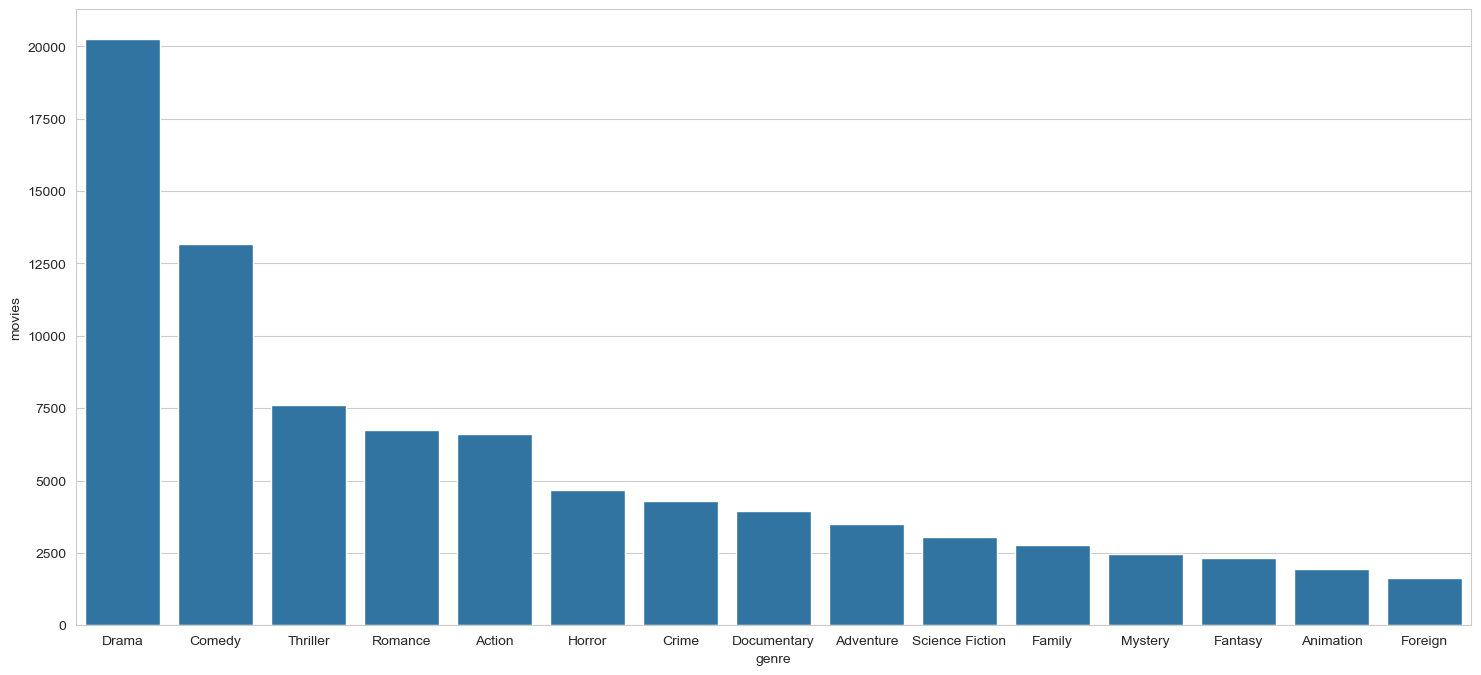

In [122]:
plt.figure(figsize=(18,8))
sns.barplot(x='genre', y='movies', data=pop_gen.head(15))
plt.show()

__Drama__ is the most commonly occuring genre with almost half the movies identifying itself as a drama film. __Comedy__ comes in at a distant second with 25% of the movies having adequate doses of humor. Other major genres represented in the top 10 are Action, Horror, Crime, Mystery, Science Fiction, Animation and Fantasy.

The next question I want to answer is the trends in the share of genres of movies across the world. Has the demand for Science Fiction movies increased? Do certain years have a disproportionate share of Animation Movies? Let's find out!

We will only be looking at trends starting 2000. We will consider only those themes that appear in the top 15 most popular genres. We will exclude Documentaries, Family and Foreign Movies from our analysis.

In [123]:
genres = ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action', 'Horror', 'Crime', 'Adventure', 'Science Fiction', 'Mystery', 'Fantasy', 'Mystery', 'Animation']


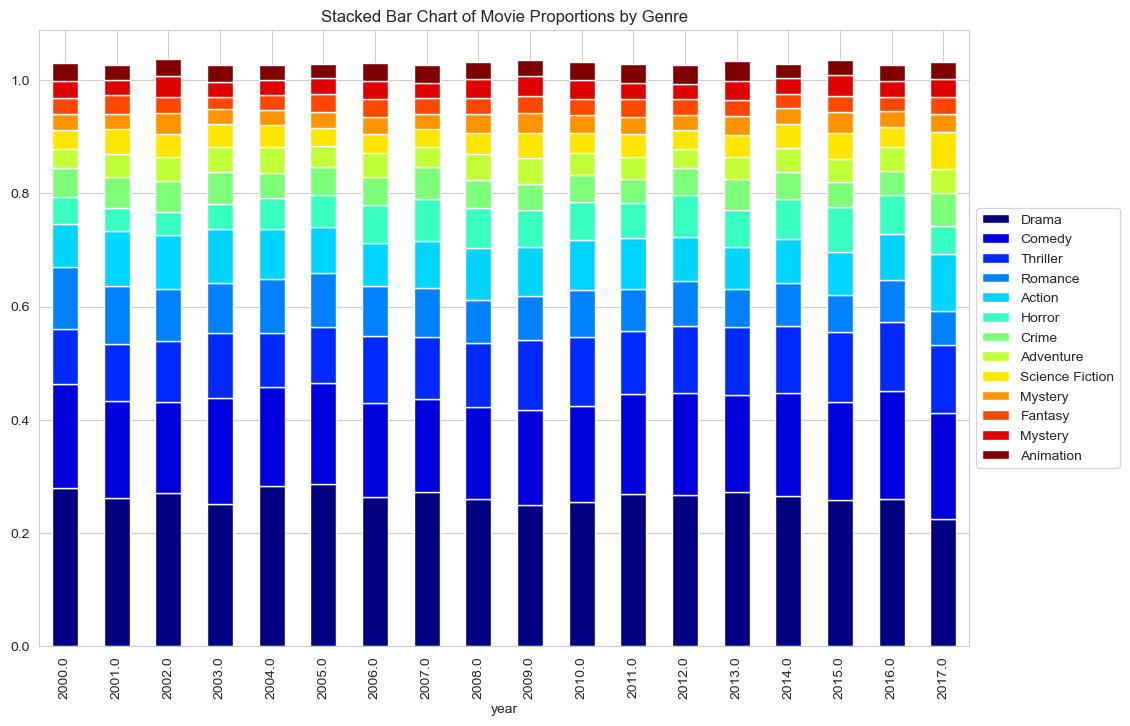

In [124]:

pop_gen_movies = gen_df[(gen_df['genre'].isin(genres)) & (gen_df['year'] >= 2000) & (gen_df['year'] <= 2017)]
ctab = pd.crosstab([pop_gen_movies['year']], pop_gen_movies['genre']).apply(lambda x: x/x.sum(), axis=1)
ctab[genres].plot(kind='bar', stacked=True, colormap='jet', figsize=(12,8)).legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Stacked Bar Chart of Movie Proportions by Genre")
plt.show()

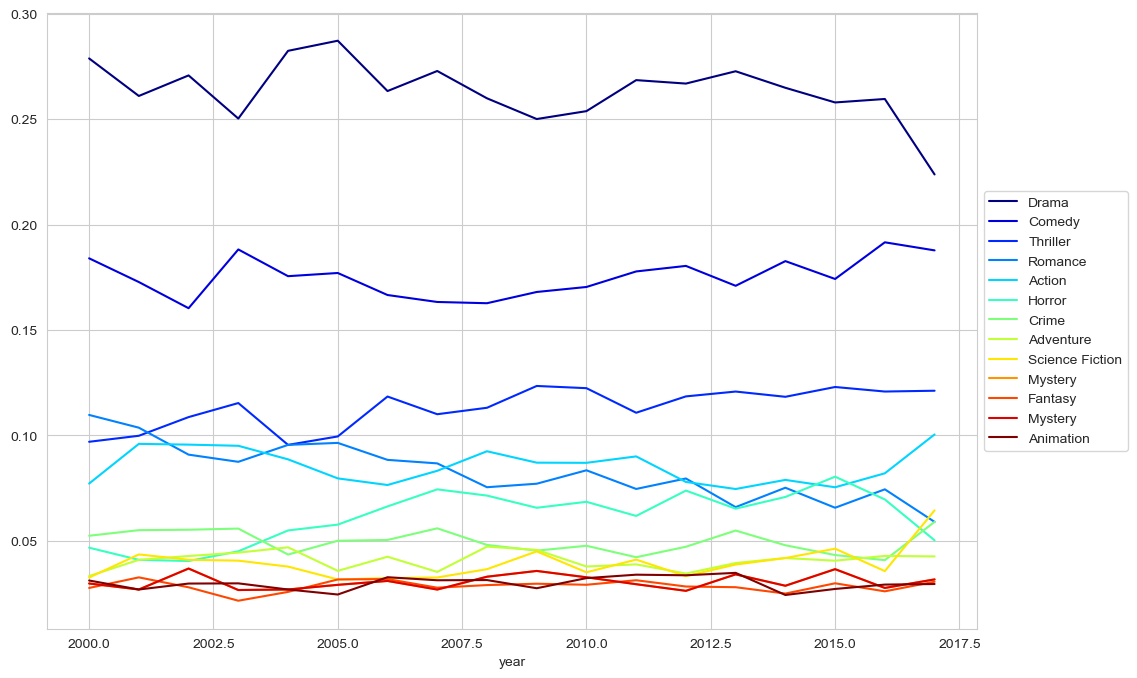

In [125]:
ctab[genres].plot(kind='line', stacked=False, colormap='jet', figsize=(12,8)).legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


The proportion of movies of each genre has remained fairly constant since the beginning of this century except for __Drama__. The proportion of drama films has fallen by over 5%. __Thriller__ movies have enjoyed a slight increase in their share.

One question that I have always had is that if some genres are particularly more successful than others. For example, we should expect Science Fiction and Fantasy Movies to bring in more revenue than other genres but when normalized with their budget, do they prove to be as successful? We will visualize two violin plots to answer this question. One will be genres versus the revenue while the other will be versus returns.

In [126]:

violin_genres = ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action', 'Horror', 'Crime', 'Science Fiction', 'Fantasy', 'Animation']
violin_movies = gen_df[(gen_df['genre'].isin(violin_genres))]

In [127]:

print(gen_df.index.is_unique)

print(gen_df.columns)

print(gen_df.columns.duplicated().sum())

print(violin_movies.index.is_unique)

False
Index(['belongs_to_collection', 'budget', 'homepage', 'id',
       'original_language', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'return', 'year', 'day', 'month',
       'genre'],
      dtype='object')
0
False


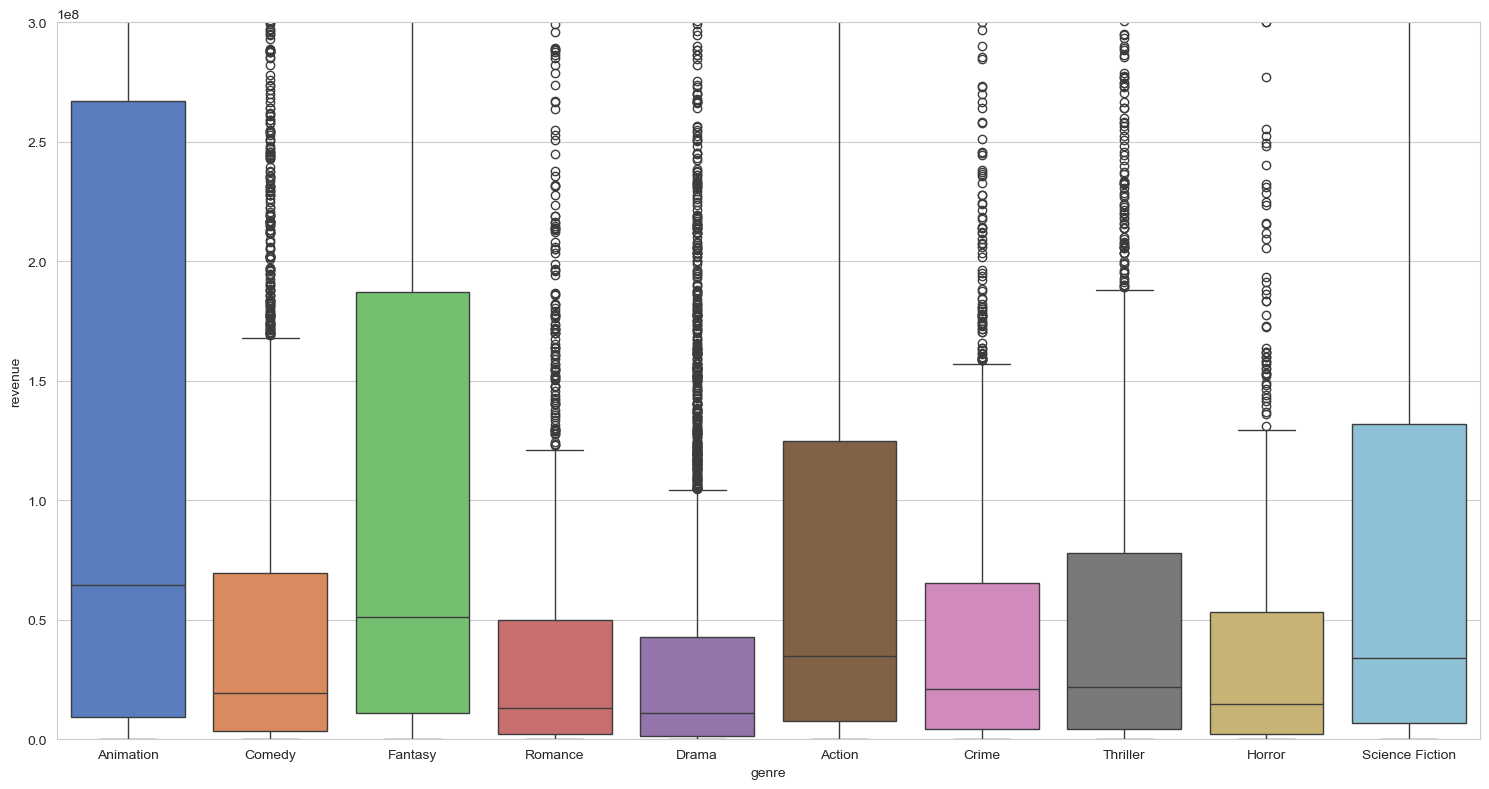

In [136]:
# Fix duplicate index issue
violin_movies.reset_index(drop=True, inplace=True)


fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(data=violin_movies, x='genre', y='revenue', hue='genre', palette='muted',
    legend=False, ax=ax )

ax.set_ylim(0, 3e8)

plt.tight_layout()
plt.show()

__Animation__ movies has the largest 25-75 range as well as the median revenue among all the genres plotted. __Fantasy__ and __Science Fiction__m have the second and third highest median revenue respectively.

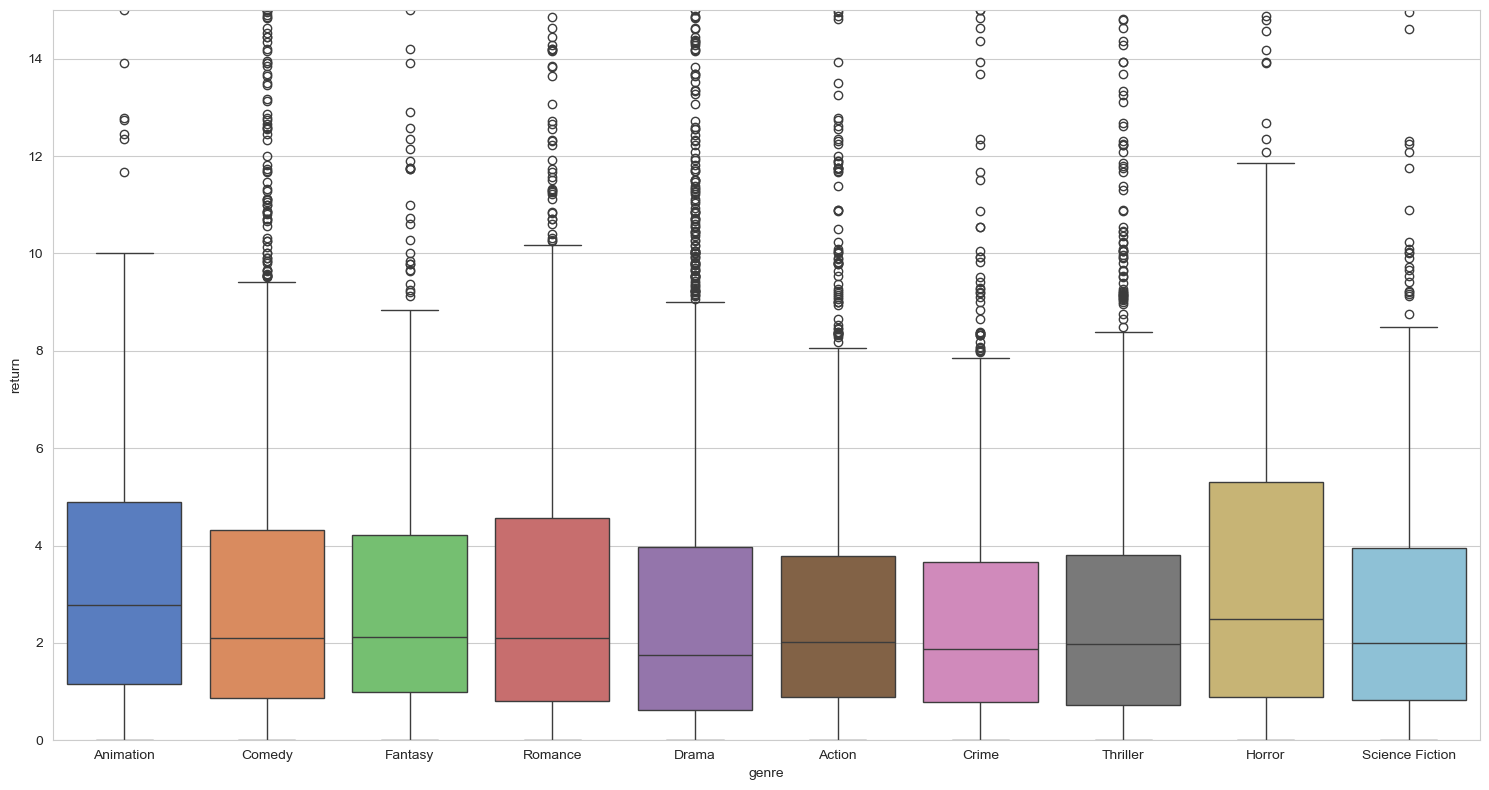

In [145]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(data=violin_movies, x='genre', y='return', hue='genre', palette='muted',
    legend=False, ax=ax )

ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

_This was all about data analysis of MovieLens 5000 movies_metadata.csv  
By: Sahaj Kumar_